In [1]:
from admm_colin.admmcolinviz import ADMMColin
from relax_and_round_smooth.fenicsviz import fenicsModel
from matplotlib import pyplot as plt
import numpy as np
import h5py
from admm_colin.admmcolinviz import _transpose_control_triangles
import math
from pathlib import Path

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# import networkx as nx
# import math

# def build_graph(n_x: int, n_y: int):
#     """Graph builder from the provided TV reference."""
#     N = n_x * n_y
#     graph = nx.Graph()
#     graph.add_nodes_from(range(N))

#     for k in range(0, N, 2):
#         if k + 1 < N:
#             graph.add_edge(k, k + 1)
#         if (k + 2) % n_y != 0 and k + 3 < N:
#             graph.add_edge(k, k + 3)
#         if (k // n_y) != 0:
#             nb = k - (n_y - 1)
#             if nb >= 0:
#                 graph.add_edge(k, nb)

#     return graph


# def build_scale(graph: nx.Graph):
#     scale = np.zeros(len(graph.edges()), dtype=float)
#     for k, (u, v) in enumerate(graph.edges()):
#         scale[k] = math.sqrt(2.0) if abs(int(u) - int(v)) == 1 else 1.0
#     return scale


# def compute_tv(control: np.ndarray, graph: nx.Graph, scale: np.ndarray) -> float:
#     diffs = []
#     for (u, v), s in zip(graph.edges(), scale):
#         diffs.append(s * abs(control[u] - control[v]))
#     return float(sum(diffs))


# graph = build_graph(64, 2*64)
# scale = build_scale(graph)
# tv_colin = compute_tv(colin_control, graph, scale)
# tv_oc = compute_tv(oc_control_disc, graph, scale)
# print("OC TV:", tv_oc)
# print("colin TV:", tv_colin)

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py


def _safe_sorted_dirs(path):
    names = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    try:
        return sorted(names, key=lambda x: float(x))
    except ValueError:
        return sorted(names)


def _last_value(x):
    arr = np.asarray(x, dtype=float)
    if arr.size == 0:
        raise ValueError("Empty dataset")
    return float(arr.reshape(-1)[-1])

In [4]:
# ----------------------------
# ADMM loader (via ADMMColin)
# ----------------------------
def load_admm_runs(base_dir="admm_colin/run_data_admm_osqp"):
    rows = []

    for alpha_name in _safe_sorted_dirs(base_dir):
        alpha_path = os.path.join(base_dir, alpha_name)
        alpha = float(alpha_name)

        for fname in sorted(os.listdir(alpha_path)):
            if not fname.endswith(".h5"):
                continue

            dim = int(os.path.splitext(fname)[0])
            try:
                admm = ADMMColin(alpha=alpha, dim=dim, base_dir=base_dir)
                series = admm.trial(0).series

                compliance = _last_value(series.compliance_disc)
                perimeter = _last_value(series.tv_disc)

                rows.append(
                    {
                        "alpha": alpha,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "source": "admm",
                        "path": os.path.join(alpha_path, fname),
                    }
                )
            except Exception as exc:
                print(f"Skipped ADMM file {os.path.join(alpha_path, fname)}: {exc}")

    return pd.DataFrame(rows)

In [5]:
# ----------------------------
# ADMM loader (via ADMMColin)
# ----------------------------
def load_admm_mip_runs(base_dir="admm_colin/run_data_admm_gurobi_mip"):
    rows = []

    for alpha_name in _safe_sorted_dirs(base_dir):
        alpha_path = os.path.join(base_dir, alpha_name)
        alpha = float(alpha_name)

        for fname in sorted(os.listdir(alpha_path)):
            if not fname.endswith(".h5"):
                continue

            dim = int(os.path.splitext(fname)[0])
            try:
                admm = ADMMColin(alpha=alpha, dim=dim, base_dir=base_dir)
                series = admm.trial(0).series

                compliance = _last_value(series.compliance_disc)
                perimeter = _last_value(series.tv_disc)

                rows.append(
                    {
                        "alpha": alpha,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "source": "admm",
                        "path": os.path.join(alpha_path, fname),
                    }
                )
            except Exception as exc:
                print(f"Skipped ADMM file {os.path.join(alpha_path, fname)}: {exc}")

    return pd.DataFrame(rows)

In [6]:
# ---------------------------------------
# OC loader (direct root-dataset reading)
# ---------------------------------------
def load_oc_runs(base_dir="oc_method/OC_results_adaptive"):
    rows = []

    for r_name in _safe_sorted_dirs(base_dir):
        r_path = os.path.join(base_dir, r_name)
        r_val = float(r_name)

        for fname in sorted(os.listdir(r_path)):
            if not fname.endswith(".h5"):
                continue

            h5_path = os.path.join(r_path, fname)
            dim = int(os.path.splitext(fname)[0])

            try:
                with h5py.File(h5_path, "r") as f:
                    #control_disc = f["control_disc"][()]
                    #control_disc_T = _transpose_control_triangles(control_disc, dim)
                    #perimeter = compute_tv(control_disc_T, graph, scale)
                    perimeter = _last_value(f["tv_disc"])
                    compliance = _last_value(f["compliance_disc"])

                rows.append(
                    {
                        "r": r_val,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "source": "oc",
                        "path": h5_path,
                    }
                )
            except Exception as exc:
                print(f"Skipped OC file {h5_path}: {exc}")

    return pd.DataFrame(rows)

In [7]:
# ---------------------------------------
# R&R loader (direct root-dataset reading)
# ---------------------------------------
def load_fenics_runs(base_dir="relax_and_round_smooth/fenics_model_tri_1e-06"):
    rows = []
    base_path = Path(base_dir)

    for alpha_name in _safe_sorted_dirs(base_path):
        alpha = float(alpha_name)
        alpha_path = base_path / alpha_name

        for file_path in sorted(alpha_path.glob("*.h5")):
            dim = int(file_path.stem)
            try:
                with h5py.File(file_path, "r") as h5f:
                    summary = h5f["summary"]
                    disc_tv = float(summary["disc_TV"][()])
                    compliance = float(summary["disc_compliance"][()])
                    runtime_total = float(summary.attrs.get("runtime_total", np.nan))

                perimeter = disc_tv / float(alpha)

                rows.append(
                    {
                        "alpha": alpha,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "runtime_total": runtime_total,
                        "source": "fenics",
                        "path": str(file_path),
                    }
                )
            except Exception as exc:
                print(f"Skipped FEniCS file {file_path}: {exc}")

    return pd.DataFrame(rows)

In [8]:
admm_df = load_admm_runs(base_dir="admm_colin/run_data_admm_gurobi_sample")
admm_mip_df = load_admm_mip_runs(base_dir="admm_colin/run_data_admm_gurobi_mip")
oc_df = load_oc_runs(base_dir="oc_method/OC_results_adaptive")
fenics_df = load_fenics_runs(base_dir="relax_and_round_smooth/fenics_model_tri_1e-06")

print(f"Loaded ADMM points: {len(admm_df)}")
print(f"Loaded ADMM MIP points: {len(admm_mip_df)}")
print(f"Loaded OC points: {len(oc_df)}")
print(f"Loaded FEniCS points: {len(fenics_df)}")

if admm_df.empty:
    print("ADMM dataframe is empty. Check run_data_admm_gurobi.")
elif admm_mip_df.empty:
    print("ADMM MIP dataframe is empty. Check run_data_admm_gurobi_mip.")
elif oc_df.empty:
    print("OC dataframe is empty. Check OC_results.")
elif fenics_df.empty:
    print("FEniCS dataframe is empty. Check fenics_model_tri.")
else:
    # Build non-overlapping bins of width 50, starting from the ADMM minimum perimeter.
    admm_perimeter_min = float(admm_df["perimeter"].min())
    admm_perimeter_max = float(admm_df["perimeter"].max())

    bin_width = 100.0
    bin_starts = np.arange(admm_perimeter_min, admm_perimeter_max, bin_width)
    bin_ends = bin_starts + bin_width

    # Drop the last bin if it would extend past the ADMM max perimeter.
    valid = bin_ends <= admm_perimeter_max
    bin_starts = bin_starts[valid]
    bin_ends = bin_ends[valid]

    if bin_starts.size == 0:
        bin_starts = np.array([admm_perimeter_min], dtype=float)
        bin_ends = np.array([admm_perimeter_min + bin_width], dtype=float)

    centers = 0.5 * (bin_starts + bin_ends)

    print(
        f"Using {len(centers)} non-overlapping bins of width {bin_width:.1f} "
        f"from {admm_perimeter_min:.2f} to {admm_perimeter_max:.2f}"
    )

    BIN_COLOR = "tab:blue"
    BIN_FILL_ALPHA = 0.12
    BIN_EDGE_ALPHA = 0.70

    
    admm_df = admm_df.loc[admm_df["compliance"]<30].copy()
    admm_mip_df = admm_mip_df.loc[admm_mip_df["compliance"]<30].copy()
    oc_df = oc_df.loc[oc_df["compliance"]<30].copy()
    fenics_df = fenics_df.loc[fenics_df["compliance"]<30].copy()

Loaded ADMM points: 110
Loaded ADMM MIP points: 100
Loaded OC points: 220
Loaded FEniCS points: 180
Using 6 non-overlapping bins of width 100.0 from 209.46 to 869.99


In [9]:
import numpy as np
import pandas as pd

max_points_per_bin = 10
seed = 0

# Reuse existing bins if available; otherwise rebuild from ADMM perimeter range.
# if "bin_starts" not in globals() or "bin_ends" not in globals():
#     if "admm_df" not in globals() or admm_df.empty:
#         raise ValueError("admm_df is not available. Run the ADMM/OC loading cell first.")

#admm_perimeter_min = float(admm_df["perimeter"].min())
#admm_perimeter_max = float(admm_df["perimeter"].max())
admm_perimeter_min = 200
admm_perimeter_max = 800
bin_width = 100.0

bin_starts = np.arange(admm_perimeter_min, admm_perimeter_max, bin_width)
bin_ends = bin_starts + bin_width
valid = bin_ends <= admm_perimeter_max
bin_starts = bin_starts[valid]
bin_ends = bin_ends[valid]


if bin_starts.size == 0:
    bin_starts = np.array([admm_perimeter_min], dtype=float)
    bin_ends = np.array([admm_perimeter_min + bin_width], dtype=float)


def cap_points_per_bin(df, bin_starts, bin_ends, max_points=10, seed=0):
    if df.empty:
        return df.copy()

    rng = np.random.default_rng(seed)
    capped_parts = []

    for left_edge, right_edge in zip(bin_starts, bin_ends):
        in_bin = df[(df["perimeter"] >= left_edge) & (df["perimeter"] < right_edge)]

        if len(in_bin) > max_points:
            keep_idx = rng.choice(in_bin.index.to_numpy(), size=max_points, replace=False)
            in_bin = in_bin.loc[np.sort(keep_idx)]

        capped_parts.append(in_bin)

    if not capped_parts:
        return df.iloc[0:0].copy()

    capped_df = pd.concat(capped_parts, axis=0)
    return capped_df.reset_index(drop=True)


if "admm_df" not in globals() or "oc_df" not in globals():
    raise ValueError("admm_df or oc_df missing. Run the plotting/data loading cell first.")

admm_df_capped = cap_points_per_bin(admm_df, bin_starts, bin_ends, max_points=max_points_per_bin, seed=seed)
admm_mip_df_capped = cap_points_per_bin(admm_mip_df, bin_starts, bin_ends, max_points=max_points_per_bin, seed=seed + 1)
oc_df_capped = cap_points_per_bin(oc_df, bin_starts, bin_ends, max_points=max_points_per_bin, seed=seed + 1)
fenics_df_capped = cap_points_per_bin(fenics_df, bin_starts, bin_ends, max_points=max_points_per_bin, seed=seed + 2)

# Verification: each bin should have <= max_points_per_bin for both methods.
admm_bin_counts = []
admm_mip_bin_counts = []
oc_bin_counts = []
fenics_bin_counts = []

for left_edge, right_edge in zip(bin_starts, bin_ends):
    admm_count = int(((admm_df_capped["perimeter"] >= left_edge) & (admm_df_capped["perimeter"] < right_edge)).sum())
    oc_count = int(((oc_df_capped["perimeter"] >= left_edge) & (oc_df_capped["perimeter"] < right_edge)).sum())
    admm_bin_counts.append(admm_count)
    admm_mip_count = int(((admm_mip_df_capped["perimeter"] >= left_edge) & (admm_mip_df_capped["perimeter"] < right_edge)).sum())
    admm_mip_bin_counts.append(admm_mip_count)
    oc_bin_counts.append(oc_count)
    fenics_count = int(((fenics_df_capped["perimeter"] >= left_edge) & (fenics_df_capped["perimeter"] < right_edge)).sum())
    fenics_bin_counts.append(fenics_count)

print("ADMM counts per bin (capped):", admm_bin_counts)
print("ADMM MIP counts per bin (capped):", admm_mip_bin_counts)
print("OC counts per bin (capped):", oc_bin_counts)
print("FEniCS counts per bin (capped):", fenics_bin_counts)
print("ADMM max count:", max(admm_bin_counts) if admm_bin_counts else 0)
print("ADMM MIP max count:", max(admm_mip_bin_counts) if admm_mip_bin_counts else 0)
print("OC max count:", max(oc_bin_counts) if oc_bin_counts else 0)
print("FEniCS max count:", max(fenics_bin_counts) if fenics_bin_counts else 0)
print("Total ADMM points after cap:", len(admm_df_capped))
print("Total ADMM MIP points after cap:", len(admm_mip_df_capped))
print("Total OC points after cap:", len(oc_df_capped))
print("Total FEniCS points after cap:", len(fenics_df_capped))

ADMM counts per bin (capped): [10, 10, 10, 10, 10, 10]
ADMM MIP counts per bin (capped): [5, 10, 10, 10, 10, 3]
OC counts per bin (capped): [10, 10, 10, 10, 10, 10]
FEniCS counts per bin (capped): [5, 9, 10, 10, 10, 10]
ADMM max count: 10
ADMM MIP max count: 10
OC max count: 10
FEniCS max count: 10
Total ADMM points after cap: 60
Total ADMM MIP points after cap: 48
Total OC points after cap: 60
Total FEniCS points after cap: 54


In [31]:
admm_df[admm_df["perimeter"] > 700]

,alpha,dim,perimeter,compliance,source,path
0,0.010875,64,869.989899,0.859460,admm,admm_colin/run_data_admm_gurobi_sample/0.01087...
1,0.011250,64,782.818326,0.944031,admm,admm_colin/run_data_admm_gurobi_sample/0.01125...
2,0.011312,64,804.333044,0.929100,admm,admm_colin/run_data_admm_gurobi_sample/0.01131...
3,0.011531,64,776.676190,0.962152,admm,admm_colin/run_data_admm_gurobi_sample/0.01153...
4,0.011750,64,769.019336,0.977734,admm,admm_colin/run_data_admm_gurobi_sample/0.01175...
5,0.011969,64,760.333044,0.986229,admm,admm_colin/run_data_admm_gurobi_sample/0.01196...
6,0.012078,64,757.847763,0.988440,admm,admm_colin/run_data_admm_gurobi_sample/0.01207...
7,0.012188,64,723.847763,1.043209,admm,admm_colin/run_data_admm_gurobi_sample/0.01218...
8,0.012406,64,775.504617,0.957733,admm,admm_colin/run_data_admm_gurobi_sample/0.01240...
9,0.012500,64,746.818326,1.020145,admm,admm_colin/run_data_admm_gurobi_sample/0.0125/...


In [15]:
ADMM_SMALL_PERI_MIN=225
ADMM_SMALL_PERI_MAX=240
ADMM_MIP_SMALL_PERI_MIN=220
ADMM_MIP_SMALL_PERI_MAX=240
OC_SMALL_PERI_MIN=230
OC_SMALL_PERI_MAX=240
FENICS_SMALL_PERI_MIN=225
FENICS_SMALL_PERI_MAX=240


ADMM_MEDIUM_PERI_MIN=460
ADMM_MEDIUM_PERI_MAX=470
ADMM_MIP_MEDIUM_PERI_MIN=460
ADMM_MIP_MEDIUM_PERI_MAX=480
OC_MEDIUM_PERI_MIN=460
OC_MEDIUM_PERI_MAX=470
FENICS_MEDIUM_PERI_MIN=460
FENICS_MEDIUM_PERI_MAX=480


ADMM_LARGE_PERI_MIN=730
ADMM_LARGE_PERI_MAX=740
ADMM_MIP_LARGE_PERI_MIN=730
ADMM_MIP_LARGE_PERI_MAX=740
OC_LARGE_PERI_MIN=720
OC_LARGE_PERI_MAX=740
FENICS_LARGE_PERI_MIN=720
FENICS_LARGE_PERI_MAX=740

Using 6 non-overlapping bins of width 100.0 from 209.46 to 782.82


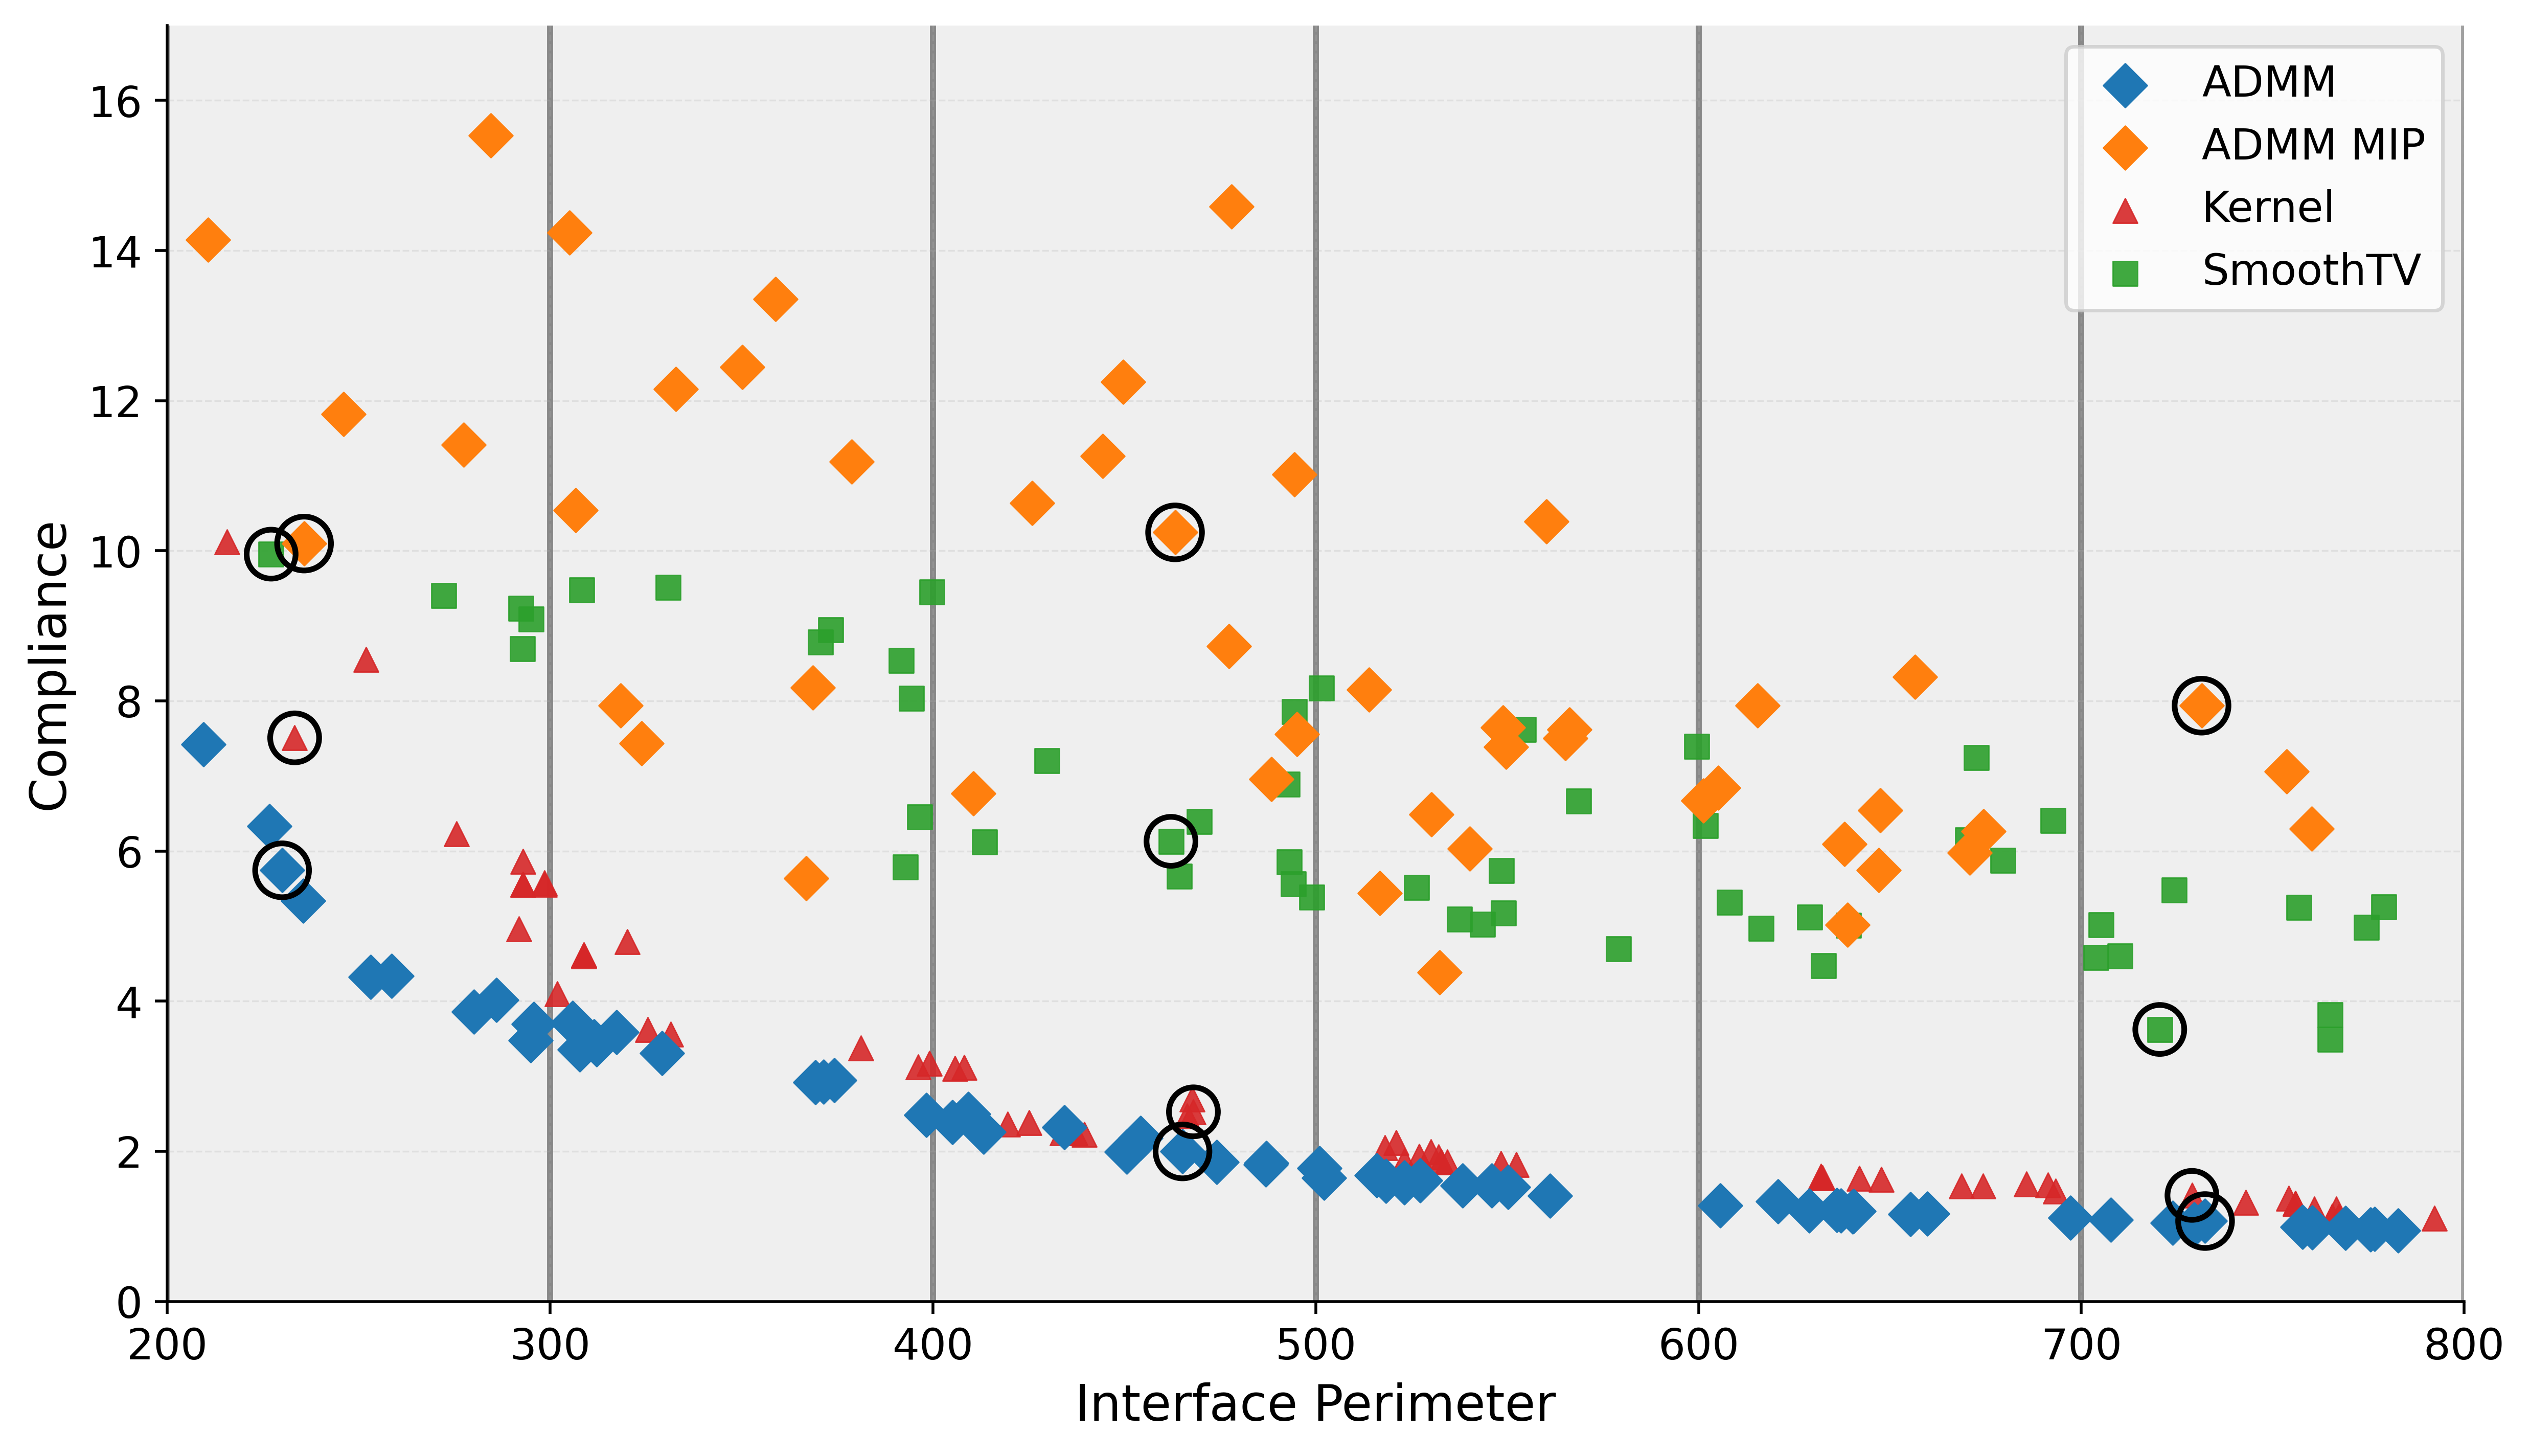

In [16]:
def circle_points(ax, df, mask, x="perimeter", y="compliance",
                  size=220, color="black", label=None, zorder=10):
    ax.scatter(
        df.loc[mask, x],
        df.loc[mask, y],
        marker="o",
        s=size,
        facecolors="none",
        edgecolors=color,
        linewidths=1.6,
        label=label,
        zorder=zorder,
    )

def circle_selected_points(
        ax,
        df,
        perimeter_ranges,
        size=230,
        color="black",
        label=None,
        rng=None,
        ):
        if rng is None:
            rng = np.random.default_rng()
        idxs = []

        for i, (peri_min, peri_max) in enumerate(perimeter_ranges):
            mask = (
                (df["perimeter"] > peri_min)
                & (df["perimeter"] < peri_max)
            )

            valid_indices = df[mask].index

            if len(valid_indices) == 0:
                continue

            idx = rng.choice(valid_indices)

            circle_points(
                ax,
                df,
                idx,
                size=size,
                color=color,
                label=label if i == 0 else None,
            )
            idxs.append(idx)
        # returns selected index for each bin (as a list) 
        return idxs



if admm_df_capped.empty:
    print("ADMM dataframe is empty. Check run_data_admm_gurobi.")
elif admm_mip_df_capped.empty:
    print("ADMM MIP dataframe is empty. Check run_data_admm_gurobi_mip.")
elif oc_df_capped.empty:
    print("OC dataframe is empty. Check OC_results.")
elif fenics_df_capped.empty:
    print("FEniCS dataframe is empty. Check fenics_model_tri.")
else:
    # Build non-overlapping bins of width 50, starting from the ADMM minimum perimeter.
    admm_perimeter_min = float(admm_df_capped["perimeter"].min())
    admm_perimeter_max = float(admm_df_capped["perimeter"].max())

    bin_width = 100.0
    bin_starts = np.arange(200, 800, bin_width)
    bin_ends = bin_starts + bin_width

    # Drop the last bin if it would extend past the ADMM max perimeter.
    valid = bin_ends <= 800
    bin_starts = bin_starts[valid]
    bin_ends = bin_ends[valid]

    if bin_starts.size == 0:
        bin_starts = np.array([admm_perimeter_min], dtype=float)
        bin_ends = np.array([admm_perimeter_min + bin_width], dtype=float)

    centers = 0.5 * (bin_starts + bin_ends)

    print(
        f"Using {len(centers)} non-overlapping bins of width {bin_width:.1f} "
        f"from {admm_perimeter_min:.2f} to {admm_perimeter_max:.2f}"
    )

    BIN_COLOR = "tab:gray"
    BIN_FILL_ALPHA = 0.12
    BIN_EDGE_ALPHA = 0.70

    cmap = plt.cm.tab10

    admm_color      = cmap(0)  # blue
    admm_mip_color  = cmap(1)  # orange
    fenics_color    = cmap(2)  # green
    kernel_color    = cmap(3)  # red
    highlight_color = "black"

    fig, ax = plt.subplots(figsize=(10, 6.5))

    # Clearly visible bins: filled rectangles and solid boundaries in the same color.
    for left_edge, right_edge in zip(bin_starts, bin_ends):
        ax.axvspan(left_edge, right_edge, color=BIN_COLOR, alpha=BIN_FILL_ALPHA, zorder=0, linewidth=0)
        ax.axvline(left_edge, color=BIN_COLOR, linewidth=1.7, alpha=BIN_EDGE_ALPHA, zorder=1)
        ax.axvline(right_edge, color=BIN_COLOR, linewidth=1.7, alpha=BIN_EDGE_ALPHA, zorder=1)

    # ADMM: diamonds
    sc1 = ax.scatter(
        admm_df_capped["perimeter"],
        admm_df_capped["compliance"],
        marker="D",
        s=75,
        #color="#e74c3c",
        color=admm_color,
        #edgecolors="black",
        linewidth=0.5,
        label="ADMM",
        zorder=4,
    )

    sc2 = ax.scatter(
            admm_mip_df_capped["perimeter"],
            admm_mip_df_capped["compliance"],
            marker="D",
            s=75,
            #color="#e74c3c",
            color=admm_mip_color,
            #edgecolors="black",
            linewidth=0.5,
            label="ADMM MIP",
            zorder=4,
        )


    # Kernel/OC: teal markers
    sc3 = ax.scatter(
        oc_df_capped["perimeter"],
        oc_df_capped["compliance"],
        marker="^",
        s=48,
        #color="teal",
        color=kernel_color,
        #edgecolors="black",
        linewidth=0.4,
        alpha=0.9,
        label="Kernel",
        zorder=3,
    )

    # Kernel/OC: teal markers
    sc4 = ax.scatter(
        fenics_df_capped["perimeter"],
        fenics_df_capped["compliance"],
        marker="s",
        s=48,
        #color="teal",
        color=fenics_color,
        #edgecolors="black",
        linewidth=0.4,
        alpha=0.9,
        label="SmoothTV",
        zorder=3,
    )


    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
    ax.legend(frameon=True, fontsize=12)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    
    admm_ranges = [
    (ADMM_SMALL_PERI_MIN, ADMM_SMALL_PERI_MAX),
    (ADMM_MEDIUM_PERI_MIN, ADMM_MEDIUM_PERI_MAX),
    (ADMM_LARGE_PERI_MIN, ADMM_LARGE_PERI_MAX),
    ]

    admm_mip_ranges = [
        (ADMM_MIP_SMALL_PERI_MIN, ADMM_MIP_SMALL_PERI_MAX),
        (ADMM_MIP_MEDIUM_PERI_MIN, ADMM_MIP_MEDIUM_PERI_MAX),
        (ADMM_MIP_LARGE_PERI_MIN, ADMM_MIP_LARGE_PERI_MAX),
    ]

    oc_ranges = [
        (OC_SMALL_PERI_MIN, OC_SMALL_PERI_MAX),
        (OC_MEDIUM_PERI_MIN, OC_MEDIUM_PERI_MAX),
        (OC_LARGE_PERI_MIN, OC_LARGE_PERI_MAX),
    ]

    fenics_ranges = [
        (FENICS_SMALL_PERI_MIN, FENICS_SMALL_PERI_MAX),
        (FENICS_MEDIUM_PERI_MIN, FENICS_MEDIUM_PERI_MAX),
        (FENICS_LARGE_PERI_MIN, FENICS_LARGE_PERI_MAX),
    ]

    rng = np.random.default_rng(0)

    admm_idxs = circle_selected_points(
        ax,
        admm_df_capped,
        admm_ranges,
        size=230,
        label="Selected ADMM",
        rng=rng,
    )

    admm_mip_idxs = circle_selected_points(
        ax,
        admm_mip_df_capped,
        admm_mip_ranges,
        size=230,
        label="Selected ADMM MIP",
        rng=rng,
    )

    oc_idxs = circle_selected_points(
        ax,
        oc_df_capped,
        oc_ranges,
        size=190,
        label="Selected Kernel",
        rng=rng,
    )

    fenics_idxs = circle_selected_points(
        ax,
        fenics_df_capped,
        fenics_ranges,
        size=190,
        label="Selected FEniCS",
        rng=rng,
    )

    
    # Bin count annotations just above the plot area.
    y_top = max(admm_df_capped["compliance"].max(), oc_df_capped["compliance"].max())
    y_bot = min(admm_df_capped["compliance"].min(), oc_df_capped["compliance"].min())
    y_text = y_top + 0.02 * (y_top - y_bot)

    for c, left_edge, right_edge in zip(centers, bin_starts, bin_ends):
        in_bin = (oc_df_capped["perimeter"] >= left_edge) & (oc_df_capped["perimeter"] < right_edge)
        n = int(in_bin.sum())
        # ax.text(c, y_text, str(n), ha="center", va="bottom", fontsize=8, color=BIN_COLOR, alpha=0.85)

    # Neutral labels and ticks (no color coding)
    ax.set_xlabel("Interface Perimeter", fontsize=14)
    ax.set_ylabel("Compliance", fontsize=14)
    ax.set_xlim(200, bin_ends[-1])
    ax.set_ylim(0, 17)
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.tick_params(axis="both", which="minor", labelsize=12)
    ax.grid(True, alpha=0.25)

    # Use actual scatter handles so legend marker shapes/colors are correct.
    handles = [sc1, sc2]
    labels = [h.get_label() for h in handles]
    # fig.legend(
    #     handles,
    #     labels,
    #     loc="upper center",
    #     bbox_to_anchor=(0.52, 1.05),
    #     ncol=2,
    #     frameon=True,
    #     fontsize=13,
    #     markerscale=1.3,
    # )
    #plt.ylim(top=30)
    plt.tight_layout(rect=(0, 0.11, 1, 1))
    plt.gcf().set_dpi(500)
    plt.show()

    df_admm = admm_df_capped.copy()
    df_oc = oc_df_capped.copy()

In [66]:
pm = admm_df_capped[(admm_df_capped["alpha"] <0.016) & (admm_df_capped["alpha"]> 0.015)]["perimeter"]

In [ ]:
oc_df_capped[(oc_df_capped["perimeter"] > pm-5 ) & (oc_df_capped["perimeter"]<pm+5)]

,r,dim,perimeter,compliance,source,path
47,3.7673,64,632.391919,1.646523,oc,oc_method/OC_results_adaptive/3.7673/64.h5
48,3.7944,64,632.048773,1.655694,oc,oc_method/OC_results_adaptive/3.7944/64.h5
49,3.7990,64,632.048773,1.665549,oc,oc_method/OC_results_adaptive/3.7990/64.h5


In [24]:
alpha_admm = admm_df_capped.loc[admm_idxs[0], "alpha"]
alpha_admm_mip = admm_mip_df_capped.loc[admm_mip_idxs[0], "alpha"]
r = oc_df_capped.loc[oc_idxs[0], "r"]
alpha_fenics = fenics_df_capped.loc[fenics_idxs[0], "alpha"]

In [25]:
admmcolin = ADMMColin(alpha=alpha_admm, dim=64, base_dir="admm_colin/run_data_admm_gurobi_sample")
colin_control = admmcolin.trial(0).iters.control_disc[-1]

In [26]:
admmmip = ADMMColin(alpha=alpha_admm_mip, dim=64, base_dir="admm_colin/run_data_admm_gurobi_mip")
mip_control = admmmip.trial(0).iters.control_disc[-1]

In [27]:
print(alpha_admm, alpha_admm_mip, r, alpha_fenics)

0.0625 0.0409375 14.2188 0.019


In [28]:
admmoc = ADMMColin(alpha=alpha_admm, dim=64, base_dir="admm_colin/run_data_admm_gurobi_sample")
from pathlib import Path
r_value = r
mesh_dim = 64
results_root=Path("oc_method/OC_results_adaptive")
folder = results_root / f"{r_value:.4f}"
file_path = folder / f"{mesh_dim}.h5"

if not file_path.exists():
    print(f"Run file not found: {file_path}")

with h5py.File(file_path, "r") as h5f:
    oc_control = h5f["control_cont"][()]
    oc_control_disc = h5f["control_disc"][()]
    #oc_control_disc_T = _transpose_control_triangles(oc_control_disc, 64)
    oc_r_attr = float(h5f.attrs.get("r", r_value))
    oc_tv_disc = float(h5f["tv_disc"][()])
    oc_compliance_disc = float(h5f["compliance_disc"][()])

In [29]:
fenics = fenicsModel(alpha=alpha_fenics, n=64, base_dir="relax_and_round_smooth/fenics_model_tri_1e-06")
fenics_control = fenics.control.vector().get_local()


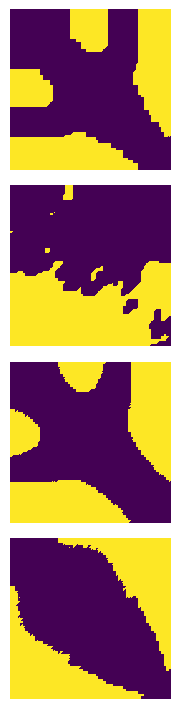

In [30]:
fig, ax = plt.subplots(figsize=(4, 7.2), nrows=4, ncols=1)
admmcolin.plot_control(colin_control, ax=ax[0])
admmcolin.plot_control(mip_control, ax=ax[1])
admmcolin.plot_control(oc_control_disc, ax=ax[2])
admmcolin.plot_control(fenics_control, ax=ax[3])
#plt.gcf().set_dpi(500)
plt.tight_layout()


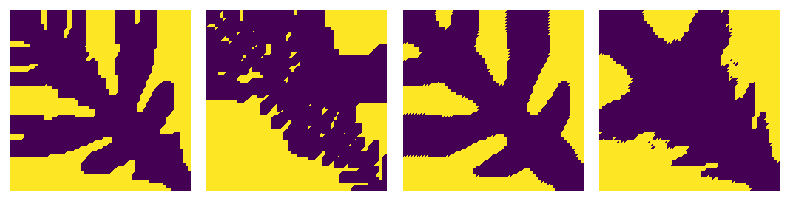

In [48]:
fig, ax = plt.subplots(figsize=(8, 4), nrows=1, ncols=4)
admmcolin.plot_control(colin_control, ax=ax[0])
admmcolin.plot_control(mip_control, ax=ax[1])
admmcolin.plot_control(oc_control_disc, ax=ax[2])
admmcolin.plot_control(fenics_control, ax=ax[3])
#plt.gcf().set_dpi(500)
plt.tight_layout()


In [ ]:
from pathlib import Path


def _safe_sorted_dirs(path):
    names = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    try:
        return sorted(names, key=lambda x: float(x))
    except ValueError:
        return sorted(names)


def load_fenics_rows(base_dir="relax_and_round_smooth/fenics_model_tri_1e-06"):
    rows = []
    base_path = Path(base_dir)

    for alpha_name in _safe_sorted_dirs(base_path):
        alpha = float(alpha_name)
        alpha_path = base_path / alpha_name

        for file_path in sorted(alpha_path.glob("*.h5")):
            dim = int(file_path.stem)
            try:
                with h5py.File(file_path, "r") as h5f:
                    summary = h5f["summary"]
                    disc_tv = float(summary["disc_TV"][()])
                    compliance = float(summary["disc_compliance"][()])
                    runtime_total = float(summary.attrs.get("runtime_total", np.nan))

                perimeter = disc_tv / float(alpha)

                rows.append(
                    {
                        "alpha": alpha,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "runtime_total": runtime_total,
                        "source": "fenics",
                        "path": str(file_path),
                    }
                )
            except Exception as exc:
                print(f"Skipped FEniCS file {file_path}: {exc}")

    return rows


fenics_rows = load_fenics_rows()
print(f"Loaded FEniCS runs: {len(fenics_rows)}")

Loaded FEniCS runs: 42


In [18]:
from pathlib import Path


def _safe_sorted_dirs(path):
    names = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    try:
        return sorted(names, key=lambda x: float(x))
    except ValueError:
        return sorted(names)


def load_admm_mip_rows(base_dir="admm_colin/run_data_admm_gurobi_mip"):
    rows = []
    base_path = Path(base_dir)

    for alpha_name in _safe_sorted_dirs(base_path):
        alpha = float(alpha_name)
        alpha_path = base_path / alpha_name

        for file_path in sorted(alpha_path.glob("*.h5")):
            dim = int(file_path.stem)
            try:
                with h5py.File(file_path, "r") as h5f:
                    summary = h5f["summary"]
                    disc_tv = float(summary["median_tv"][()])
                    compliance = float(summary["median_compliance"][()])
                    #runtime_total = float(summary.attrs.get("runtime_total", np.nan))

                perimeter = dim * disc_tv / float(alpha)

                rows.append(
                    {
                        "alpha": alpha,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "source": "admm MIP",
                        "path": str(file_path),
                    }
                )
            except Exception as exc:
                print(f"Skipped FEniCS file {file_path}: {exc}")

    return rows


admm_mip_rows = load_admm_mip_rows()
print(f"Loaded ADMM MIP runs: {len(admm_mip_rows)}")

Loaded ADMM MIP runs: 47


In [ ]:
admm_mip_df = pd.DataFrame(admm_mip_rows)
admm_mip_df = admm_mip_df.sort_values(["alpha", "dim"]).reset_index(drop=True)
admm_mip_df

### Runtime comparisons

In [ ]:
admmcolin = ADMMColin(alpha=0.01, dim=64, base_dir="admm_colin/run_data_admm_gurobi")
admmmip = ADMMColin(alpha=0.01, dim=64, base_dir="admm_colin/run_data_admm_gurobi_mip")
admosqp = ADMMColin(alpha=0.01, dim=64, base_dir="admm_colin/run_data_admm_osqp")

Loaded OC runtime from: oc_method/OC_results_mew/7.04/64.h5


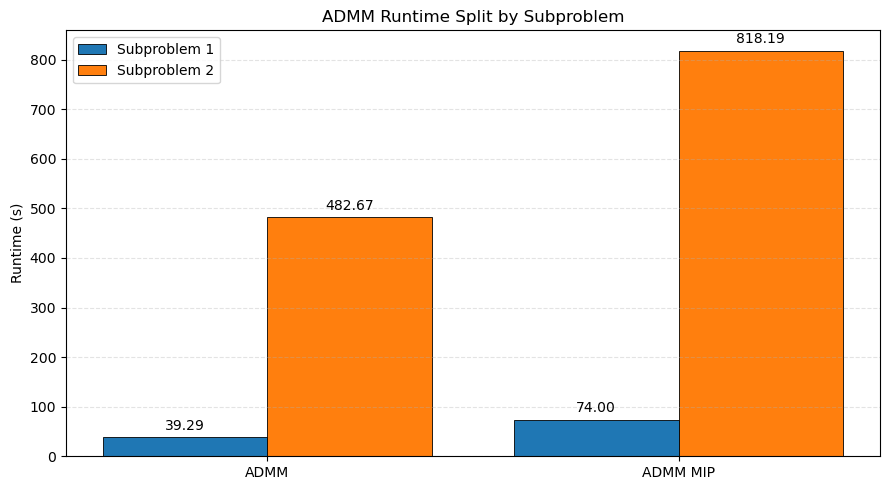

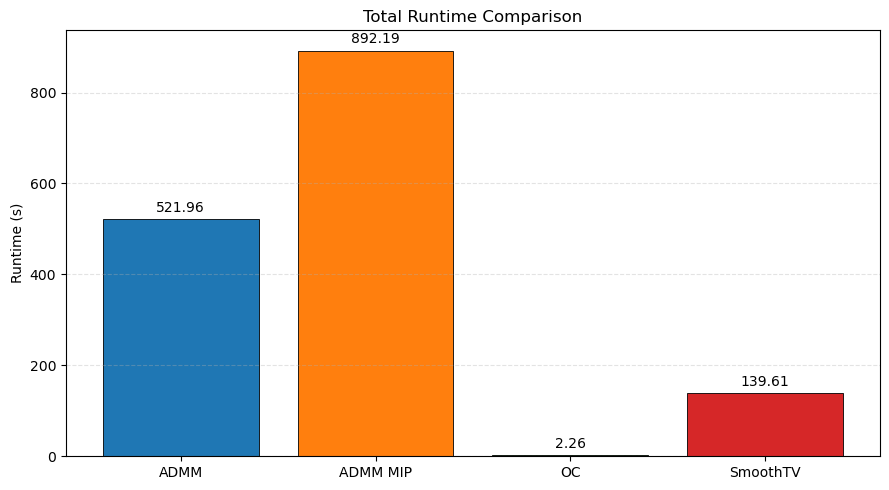

ADMM total runtime: 521.961 s
ADMM MIP total runtime: 892.194 s
OC total runtime: 2.264 s
SmoothTV total runtime: 139.614 s


In [ ]:
# Runtime extraction
admm_runtime_sub1 = float(np.sum(admmcolin.trial(0).series.runtime_sub1))
admm_runtime_sub2 = float(np.sum(admmcolin.trial(0).series.runtime_sub2))
admm_runtime_total = admm_runtime_sub1 + admm_runtime_sub2

admm_mip_runtime_sub1 = float(np.sum(admmmip.trial(0).series.runtime_sub1))
admm_mip_runtime_sub2 = float(np.sum(admmmip.trial(0).series.runtime_sub2))
admm_mip_runtime_total = admm_mip_runtime_sub1 + admm_mip_runtime_sub2

admm_osqp_runtime_sub1 = float(np.sum(admosqp.trial(0).series.runtime_sub1))
admm_osqp_runtime_sub2 = float(np.sum(admosqp.trial(0).series.runtime_sub2))
admm_osqp_runtime_total = admm_osqp_runtime_sub1 + admm_osqp_runtime_sub2

fenics_runtime_total = float(
    getattr(fenics, "total_runtime", getattr(fenics, "runtime_total", np.nan))
)


# OC runtime loader (requested folder first, with fallback)
def _load_oc_runtime_total(r_value, mesh_size):
    candidate_roots = [
        Path("oc_method/OC_results_mew"),
        Path("oc_method/OC_results_new"),
    ]

    last_attempt = None
    for root in candidate_roots:
        candidate = root / f"{float(r_value):.2f}" / f"{int(mesh_size)}.h5"
        last_attempt = candidate
        if candidate.exists():
            with h5py.File(candidate, "r") as h5f:
                return float(h5f.attrs.get("runtime_total", np.nan)), candidate

    print(f"OC runtime file not found. Last tried: {last_attempt}")
    return np.nan, None


oc_runtime_total, oc_runtime_path = _load_oc_runtime_total(r, mesh_dim)
if oc_runtime_path is not None:
    print(f"Loaded OC runtime from: {oc_runtime_path}")


# -------- Plot 1: ADMM split runtimes (touching half-width bars) --------
methods = ["ADMM Gurobi", "ADMM MIP Gurobi", "ADMM OSQP"]
sub1_vals = np.array([admm_runtime_sub1, admm_mip_runtime_sub1, admm_osqp_runtime_sub1], dtype=float)
sub2_vals = np.array([admm_runtime_sub2, admm_mip_runtime_sub2, admm_osqp_runtime_sub2], dtype=float)


x = np.arange(len(methods), dtype=float)
bar_w = 0.40

fig, ax = plt.subplots(figsize=(9, 5))

bars_sub1 = ax.bar(
    x - bar_w / 2,
    sub1_vals,
    width=bar_w,
    color="tab:blue",
    edgecolor="black",
    linewidth=0.6,
    label="Subproblem 1",
)

bars_sub2 = ax.bar(
    x + bar_w / 2,
    sub2_vals,
    width=bar_w,
    color="tab:orange",
    edgecolor="black",
    linewidth=0.6,
    label="Subproblem 2",
)

ax.bar_label(bars_sub1, fmt="%.2f", padding=3, fontsize=10)
ax.bar_label(bars_sub2, fmt="%.2f", padding=3, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Runtime (s)")
ax.set_title("ADMM Runtime Split by Subproblem")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


# -------- Plot 2: Total runtime comparison --------
total_labels = ["ADMM", "ADMM MIP", "OC", "SmoothTV"]
total_vals = np.array(
    [
        admm_runtime_total,
        admm_mip_runtime_total,
        oc_runtime_total,
        fenics_runtime_total,
    ],
    dtype=float,
)

fig, ax = plt.subplots(figsize=(9, 5))
bars_total = ax.bar(
    total_labels,
    total_vals,
    color=["tab:blue", "tab:orange", "tab:green", "tab:red"],
    edgecolor="black",
    linewidth=0.6,
)

ax.bar_label(bars_total, fmt="%.2f", padding=3, fontsize=10)
ax.set_ylabel("Runtime (s)")
ax.set_title("Total Runtime Comparison")
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


print(f"ADMM total runtime: {admm_runtime_total:.3f} s")
print(f"ADMM MIP total runtime: {admm_mip_runtime_total:.3f} s")
print(f"OC total runtime: {oc_runtime_total:.3f} s")
print(f"SmoothTV total runtime: {fenics_runtime_total:.3f} s")

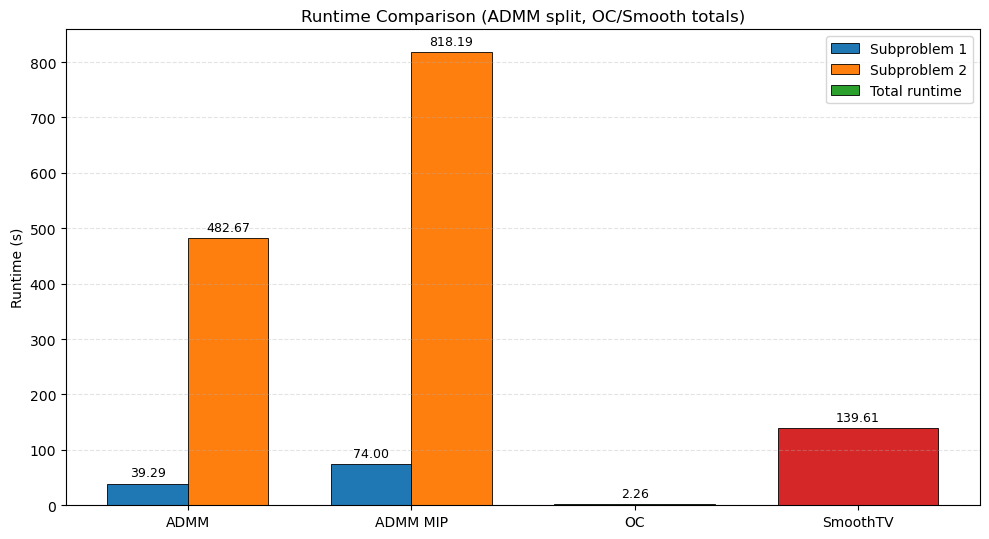

In [60]:
# Single combined runtime plot:
# - ADMM and ADMM MIP are split into touching half-bars (Sub1/Sub2)
# - OC and SmoothTV are shown as single total-runtime bars

# Recompute if needed (safe if already present)
admm_runtime_sub1 = float(np.sum(admmcolin.trial(0).series.runtime_sub1))
admm_runtime_sub2 = float(np.sum(admmcolin.trial(0).series.runtime_sub2))
admm_runtime_total = admm_runtime_sub1 + admm_runtime_sub2

admm_mip_runtime_sub1 = float(np.sum(admmmip.trial(0).series.runtime_sub1))
admm_mip_runtime_sub2 = float(np.sum(admmmip.trial(0).series.runtime_sub2))
admm_mip_runtime_total = admm_mip_runtime_sub1 + admm_mip_runtime_sub2

fenics_runtime_total = float(
    getattr(fenics, "total_runtime", getattr(fenics, "runtime_total", np.nan))
)

if "oc_runtime_total" not in globals() or np.isnan(oc_runtime_total):
    candidate_roots = [Path("oc_method/OC_results_mew"), Path("oc_method/OC_results_new")]
    oc_runtime_total = np.nan
    for root in candidate_roots:
        oc_path = root / f"{float(r):.2f}" / f"{int(mesh_dim)}.h5"
        if oc_path.exists():
            with h5py.File(oc_path, "r") as h5f:
                oc_runtime_total = float(h5f.attrs.get("runtime_total", np.nan))
            break

labels = ["ADMM", "ADMM MIP", "OC", "SmoothTV"]
x = np.arange(len(labels), dtype=float)
full_w = 0.72
half_w = full_w / 2.0

fig, ax = plt.subplots(figsize=(10, 5.5))

# Split bars for ADMM
admm_sub1_bar = ax.bar(
    x[0] - half_w / 2,
    admm_runtime_sub1,
    width=half_w,
    color="tab:blue",
    edgecolor="black",
    linewidth=0.6,
    label="Subproblem 1",
)
admm_sub2_bar = ax.bar(
    x[0] + half_w / 2,
    admm_runtime_sub2,
    width=half_w,
    color="tab:orange",
    edgecolor="black",
    linewidth=0.6,
    label="Subproblem 2",
)

# Split bars for ADMM MIP
admm_mip_sub1_bar = ax.bar(
    x[1] - half_w / 2,
    admm_mip_runtime_sub1,
    width=half_w,
    color="tab:blue",
    edgecolor="black",
    linewidth=0.6,
)
admm_mip_sub2_bar = ax.bar(
    x[1] + half_w / 2,
    admm_mip_runtime_sub2,
    width=half_w,
    color="tab:orange",
    edgecolor="black",
    linewidth=0.6,
)

# Single bars for OC and SmoothTV totals
oc_bar = ax.bar(
    x[2],
    oc_runtime_total,
    width=full_w,
    color="tab:green",
    edgecolor="black",
    linewidth=0.6,
    label="Total runtime",
)
smooth_bar = ax.bar(
    x[3],
    fenics_runtime_total,
    width=full_w,
    color="tab:red",
    edgecolor="black",
    linewidth=0.6,
)

# Labels on all bars
for bars in [admm_sub1_bar, admm_sub2_bar, admm_mip_sub1_bar, admm_mip_sub2_bar, oc_bar, smooth_bar]:
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Runtime (s)")
ax.set_title("Runtime Comparison (ADMM split, OC/Smooth totals)")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

In [31]:
import numpy as np
import matplotlib.pyplot as plt


def plot_bulb_violin_by_bins(
    df,
    color,
    method_name,
    x_col="perimeter",
    y_col="compliance",
    x_label="Perimeter bin",
    y_label="Compliance",
):
    if "bin_starts" not in globals() or "bin_ends" not in globals():
        raise ValueError("bin_starts and bin_ends must be defined before plotting.")
    if x_col not in df.columns or y_col not in df.columns:
        raise ValueError(f"Expected columns '{x_col}' and '{y_col}' in the dataframe.")

    centers = 0.5 * (bin_starts + bin_ends)
    widths = (bin_ends - bin_starts)

    values_all = []
    counts = []
    means = []
    stds = []

    for left_edge, right_edge in zip(bin_starts, bin_ends):
        vals = df.loc[
            (df[x_col] >= left_edge) & (df[x_col] < right_edge), y_col
        ].dropna().to_numpy(dtype=float)

        values_all.append(vals)
        counts.append(int(vals.size))
        if vals.size > 0:
            means.append(float(np.mean(vals)))
            stds.append(float(np.std(vals, ddof=0)))
        else:
            means.append(np.nan)
            stds.append(np.nan)

    nonempty_idx = [i for i, arr in enumerate(values_all) if arr.size > 0]

    fig, ax = plt.subplots(figsize=(11, 6))

    if nonempty_idx:
        vp = ax.violinplot(
            [values_all[i] for i in nonempty_idx],
            positions=centers[nonempty_idx],
            widths=0.78 * widths[nonempty_idx],
            showmeans=False,
            showmedians=False,
            showextrema=True,
        )

        for body in vp["bodies"]:
            body.set_facecolor(color)
            body.set_edgecolor(color)
            body.set_alpha(0.45)
            body.set_linewidth(0.9)

        for key in ["cbars", "cmins", "cmaxes"]:
            vp[key].set_edgecolor(color)
            vp[key].set_linewidth(1.0)
            vp[key].set_alpha(0.95)

        mean_x = centers[nonempty_idx]
        mean_y = np.asarray([means[i] for i in nonempty_idx], dtype=float)
        std_y = np.asarray([stds[i] for i in nonempty_idx], dtype=float)

        ax.errorbar(
            mean_x,
            mean_y,
            yerr=std_y,
            fmt="none",
            ecolor=color,
            elinewidth=1.2,
            capsize=3,
            alpha=0.95,
            zorder=3,
        )

    y_vals = df[y_col].dropna().to_numpy(dtype=float)
    if y_vals.size == 0:
        y_min, y_max = 0.0, 1.0
    else:
        y_min, y_max = float(np.min(y_vals)), float(np.max(y_vals))
        if np.isclose(y_min, y_max):
            y_min -= 0.5
            y_max += 0.5

    y_span = y_max - y_min
    y_top = y_max + 0.28 * y_span
    y_text = y_max + 0.05 * y_span

    for i, c in enumerate(centers):
        if counts[i] > 0:
            txt = f"n={counts[i]}\n$\\mu$={means[i]:.2f}\n$\\sigma$={stds[i]:.2f}"
        else:
            txt = "n=0\n$\\mu$=nan\n$\\sigma$=nan"
        ax.text(c, y_text, txt, ha="center", va="bottom", fontsize=12)

    #ax.set_title(method_name, fontsize=12)
    ax.set_xlabel(x_label, fontsize=16)
    ax.set_ylabel(y_label, fontsize=16)
    ax.set_xticks(centers)
    ax.set_xticklabels([f"{int(round(v))}" for v in centers])
    ax.set_ylim(y_min - 0.04 * y_span, y_top)
    ax.set_xlim(float(bin_starts.min()) - 0.6 * widths[0], float(bin_ends.max()) + 0.6 * widths[-1])
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.tick_params(axis="both", which="minor", labelsize=14)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_alpha(0.8)

    ax.grid(axis="y", linestyle="-", alpha=0.15)
    plt.tight_layout()
    plt.gcf().set_dpi(500)
    plt.show()

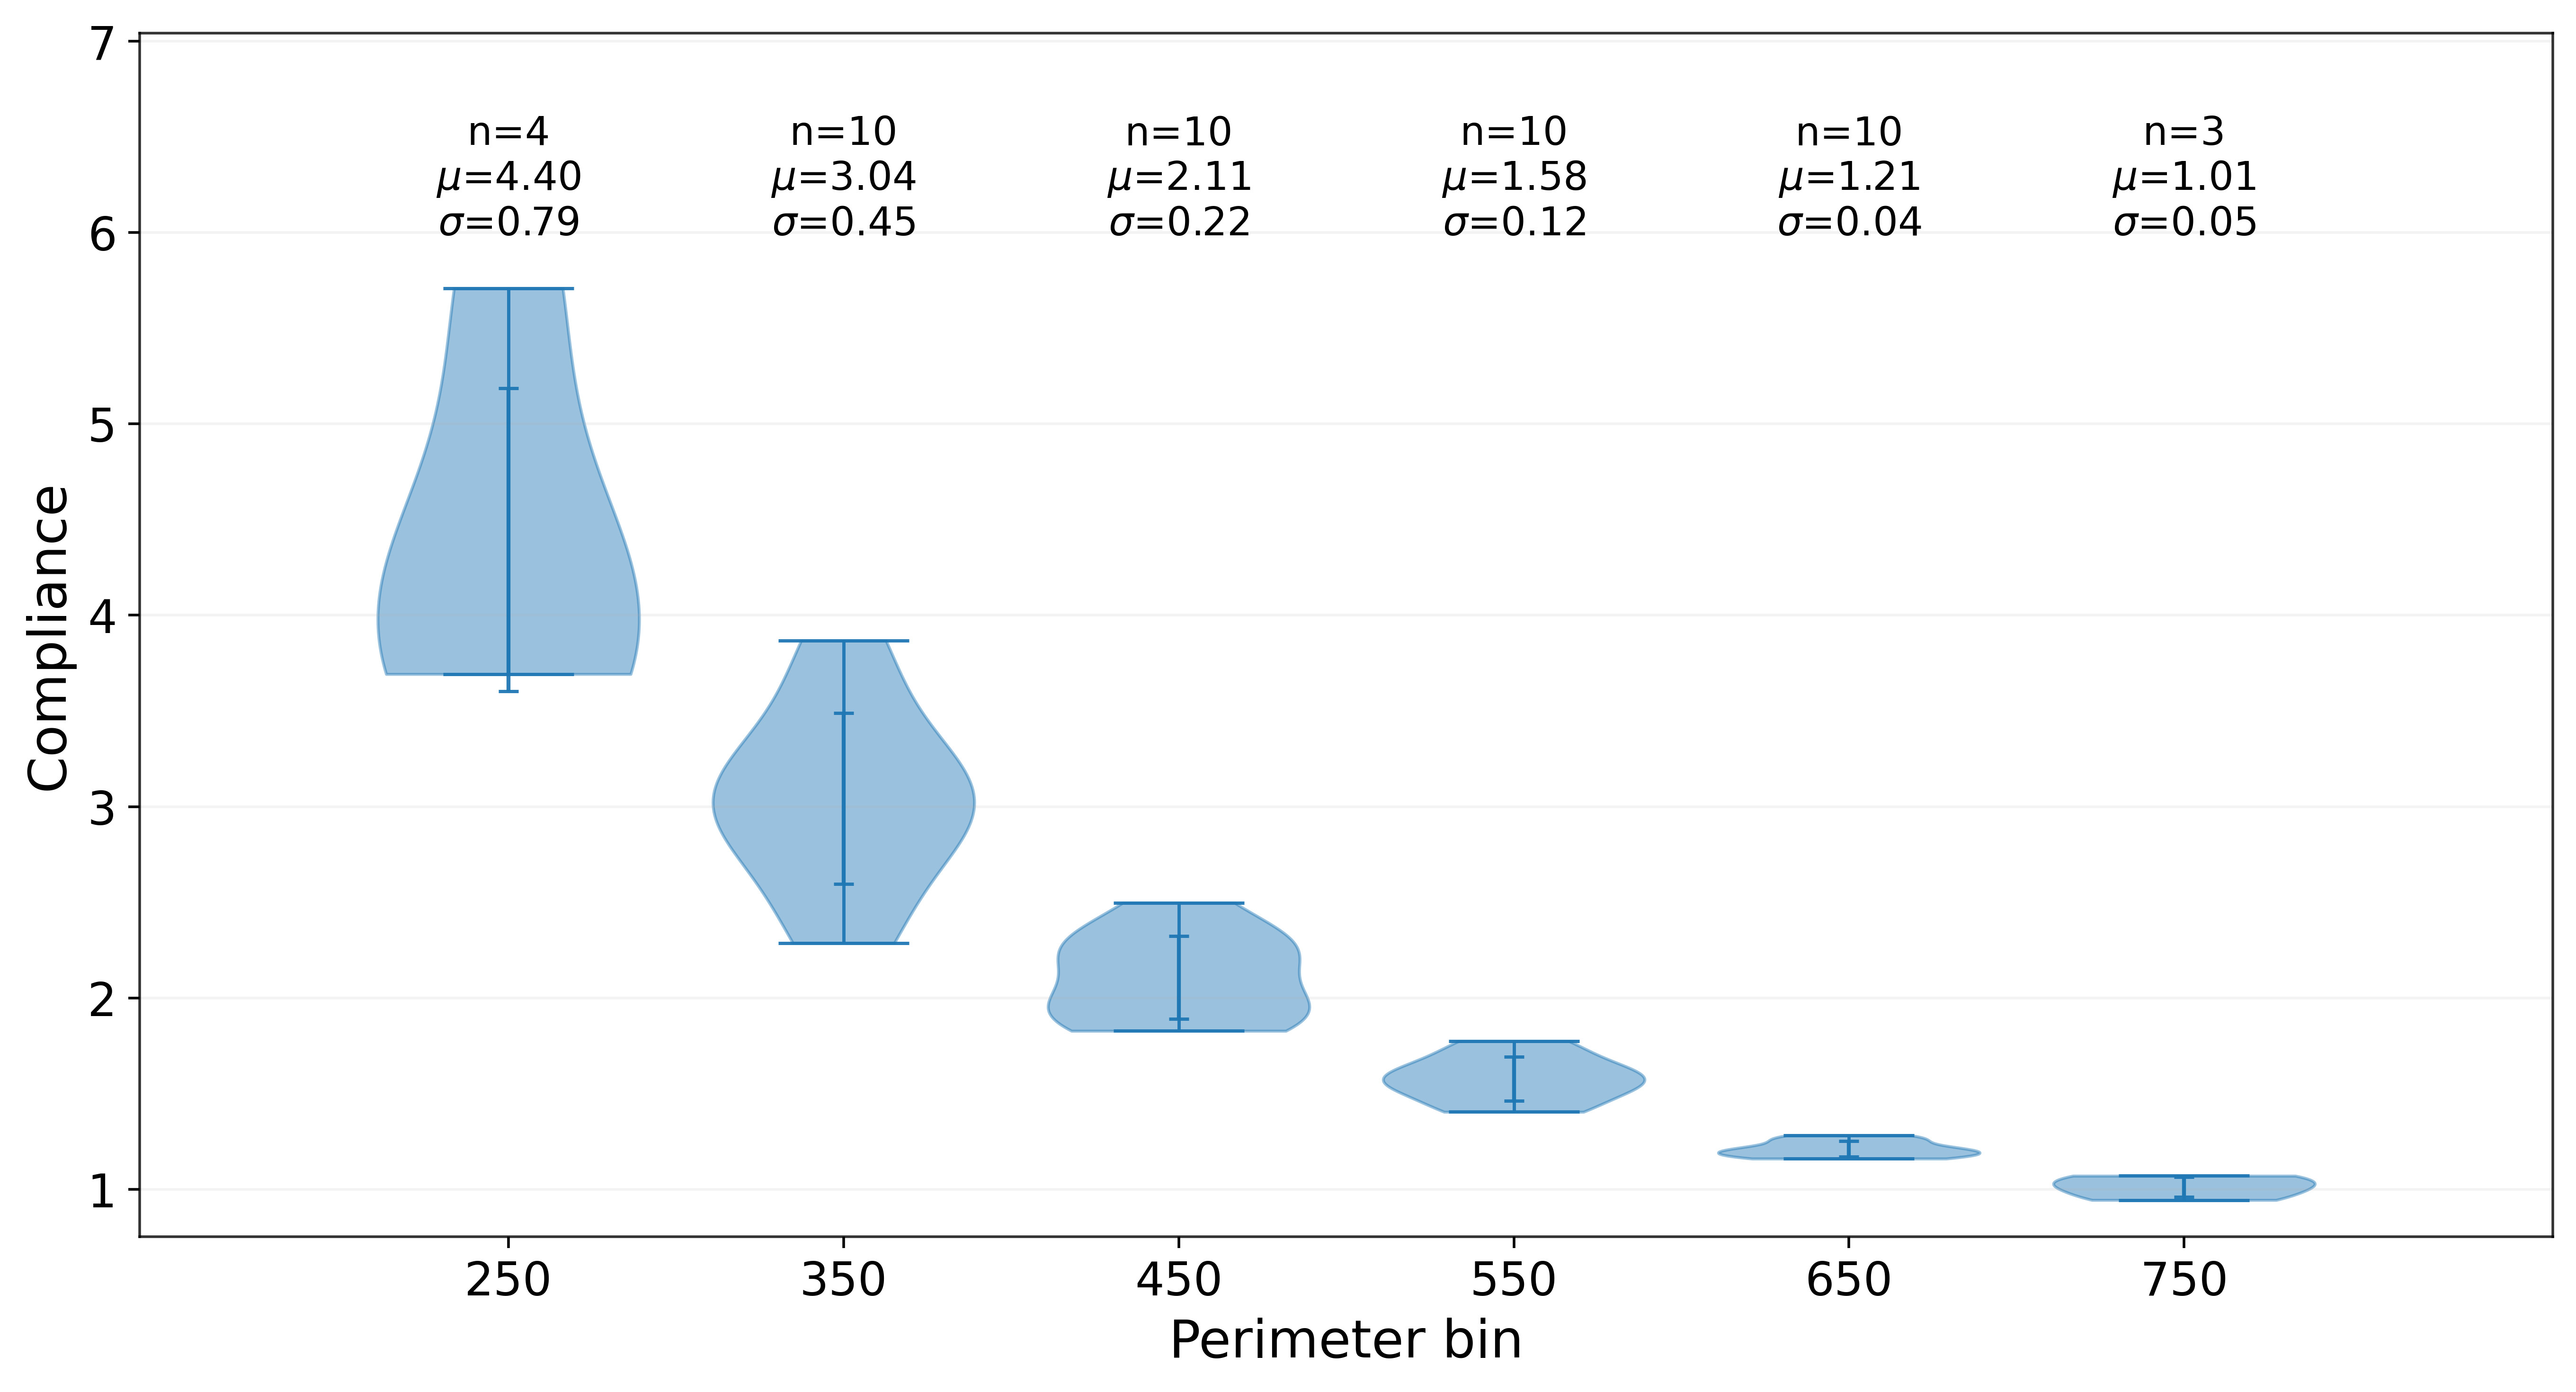

In [21]:
plot_bulb_violin_by_bins(admm_df_capped, admm_color, "ADMM")

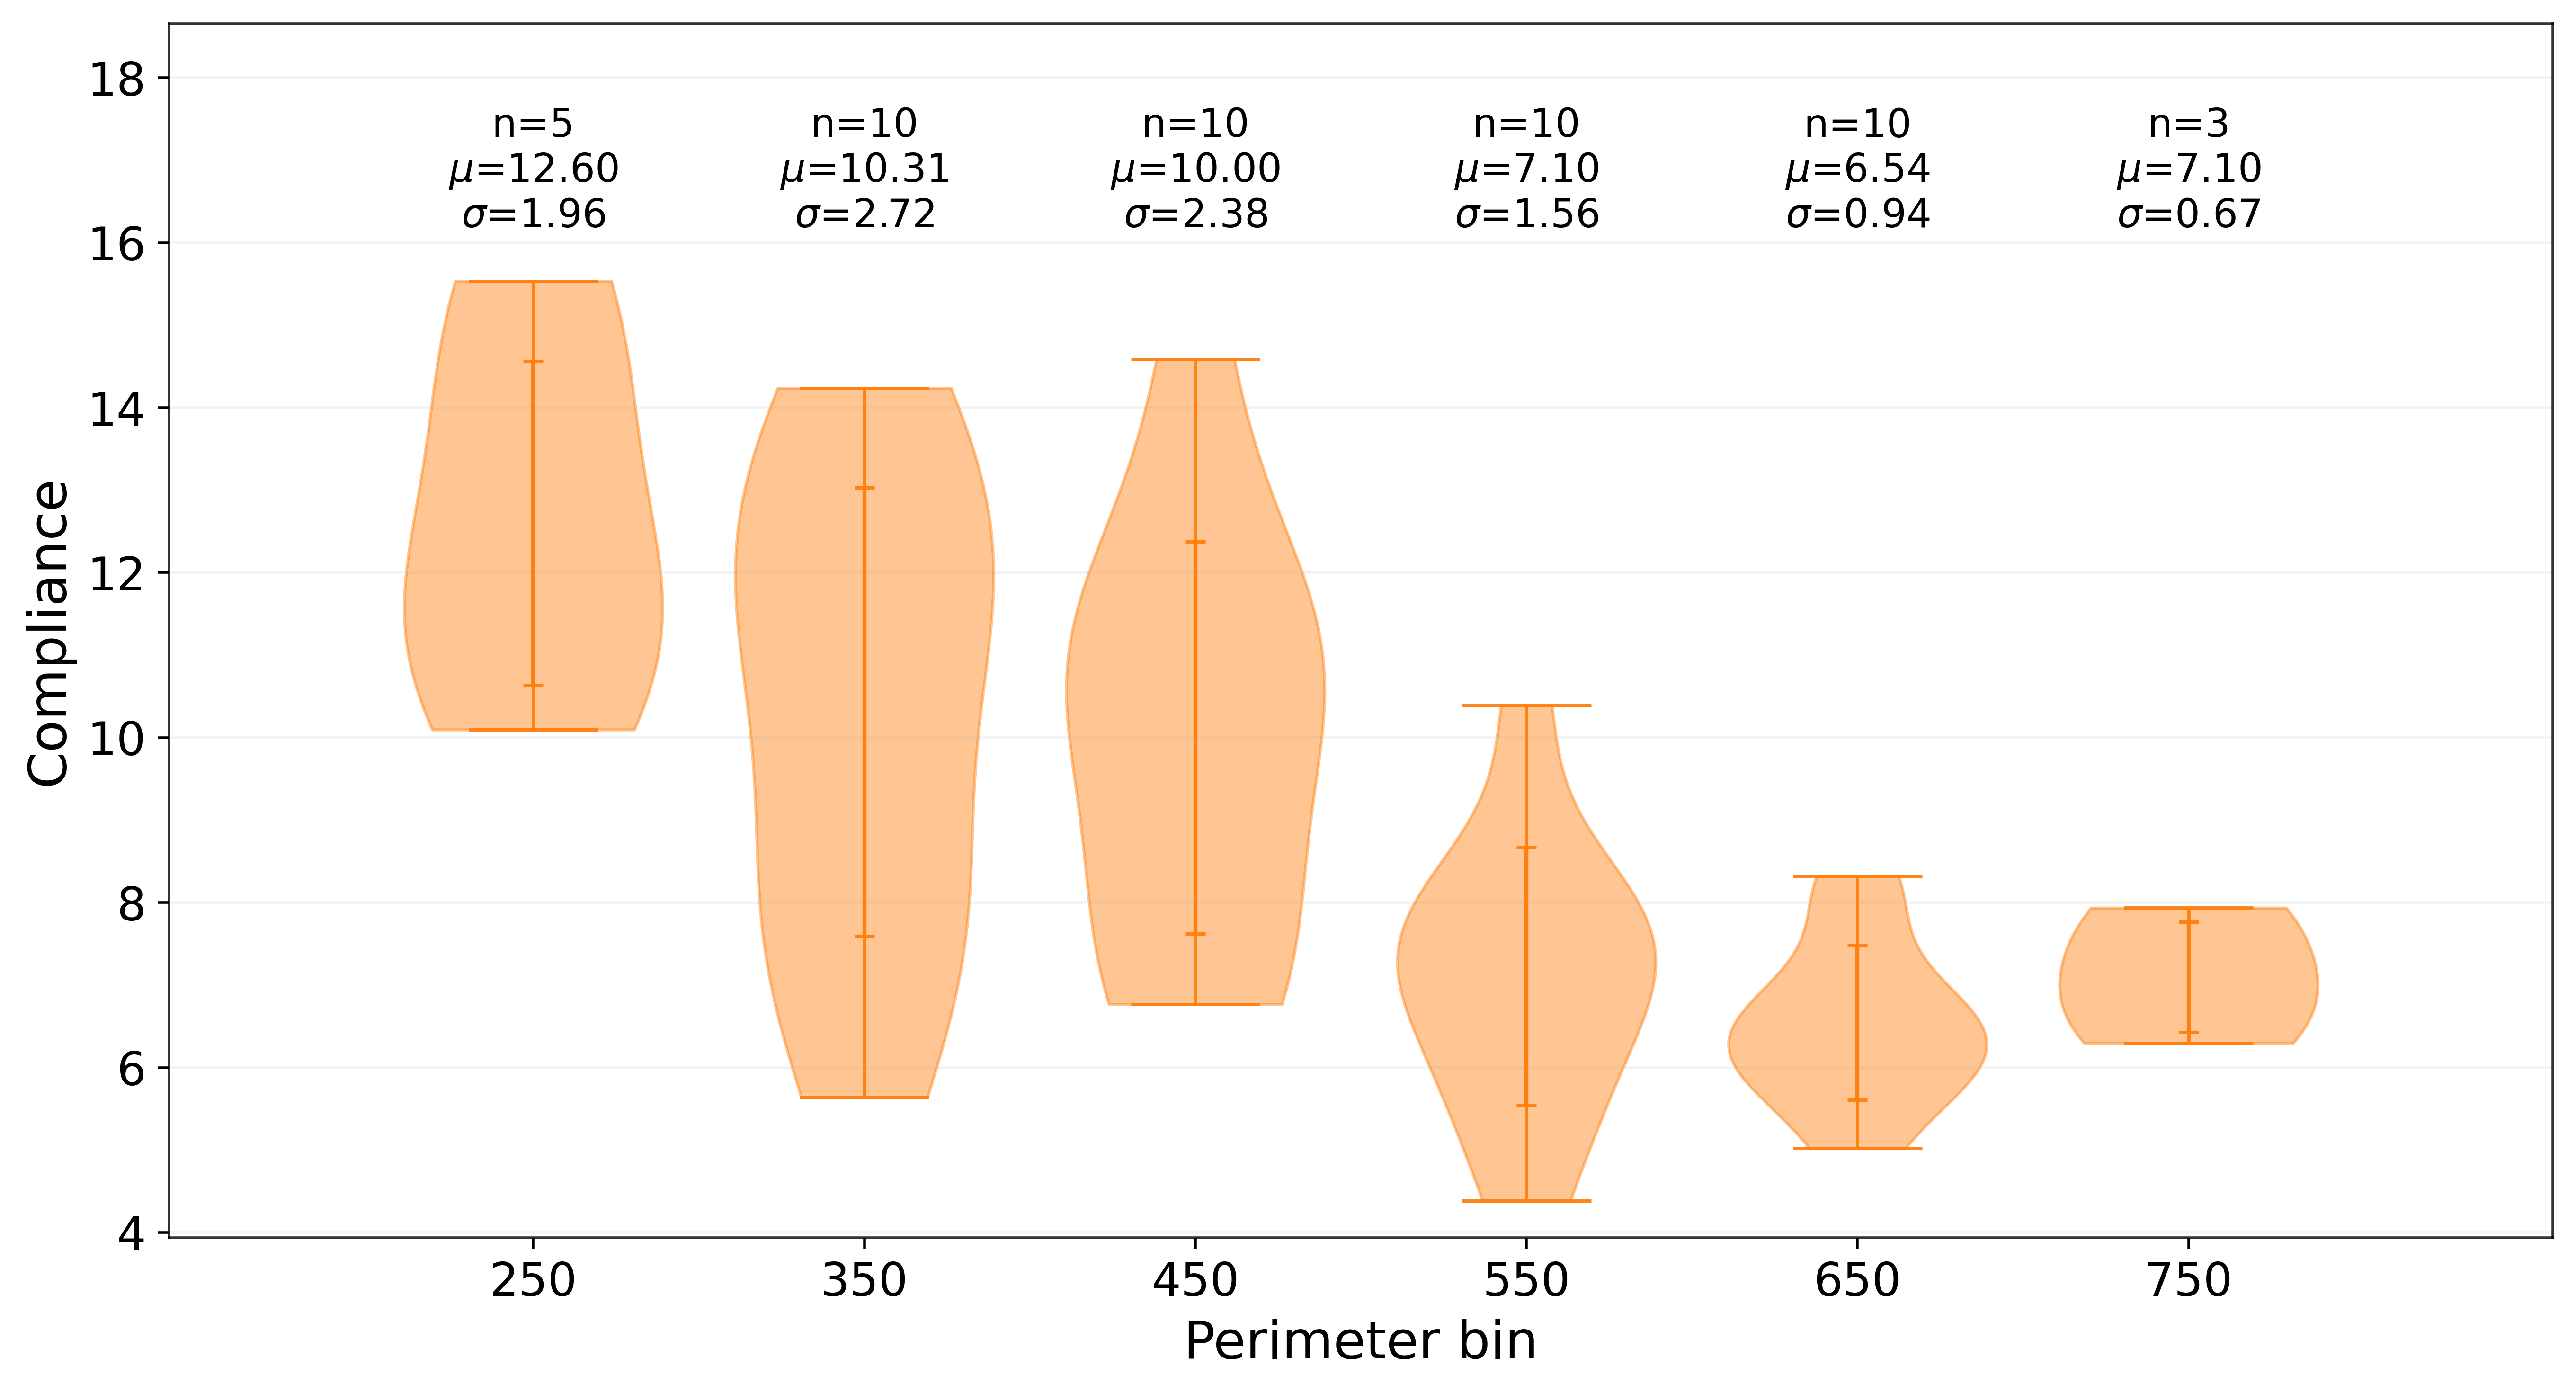

In [32]:
plot_bulb_violin_by_bins(admm_mip_df_capped, admm_mip_color,"ADMM-MIP")

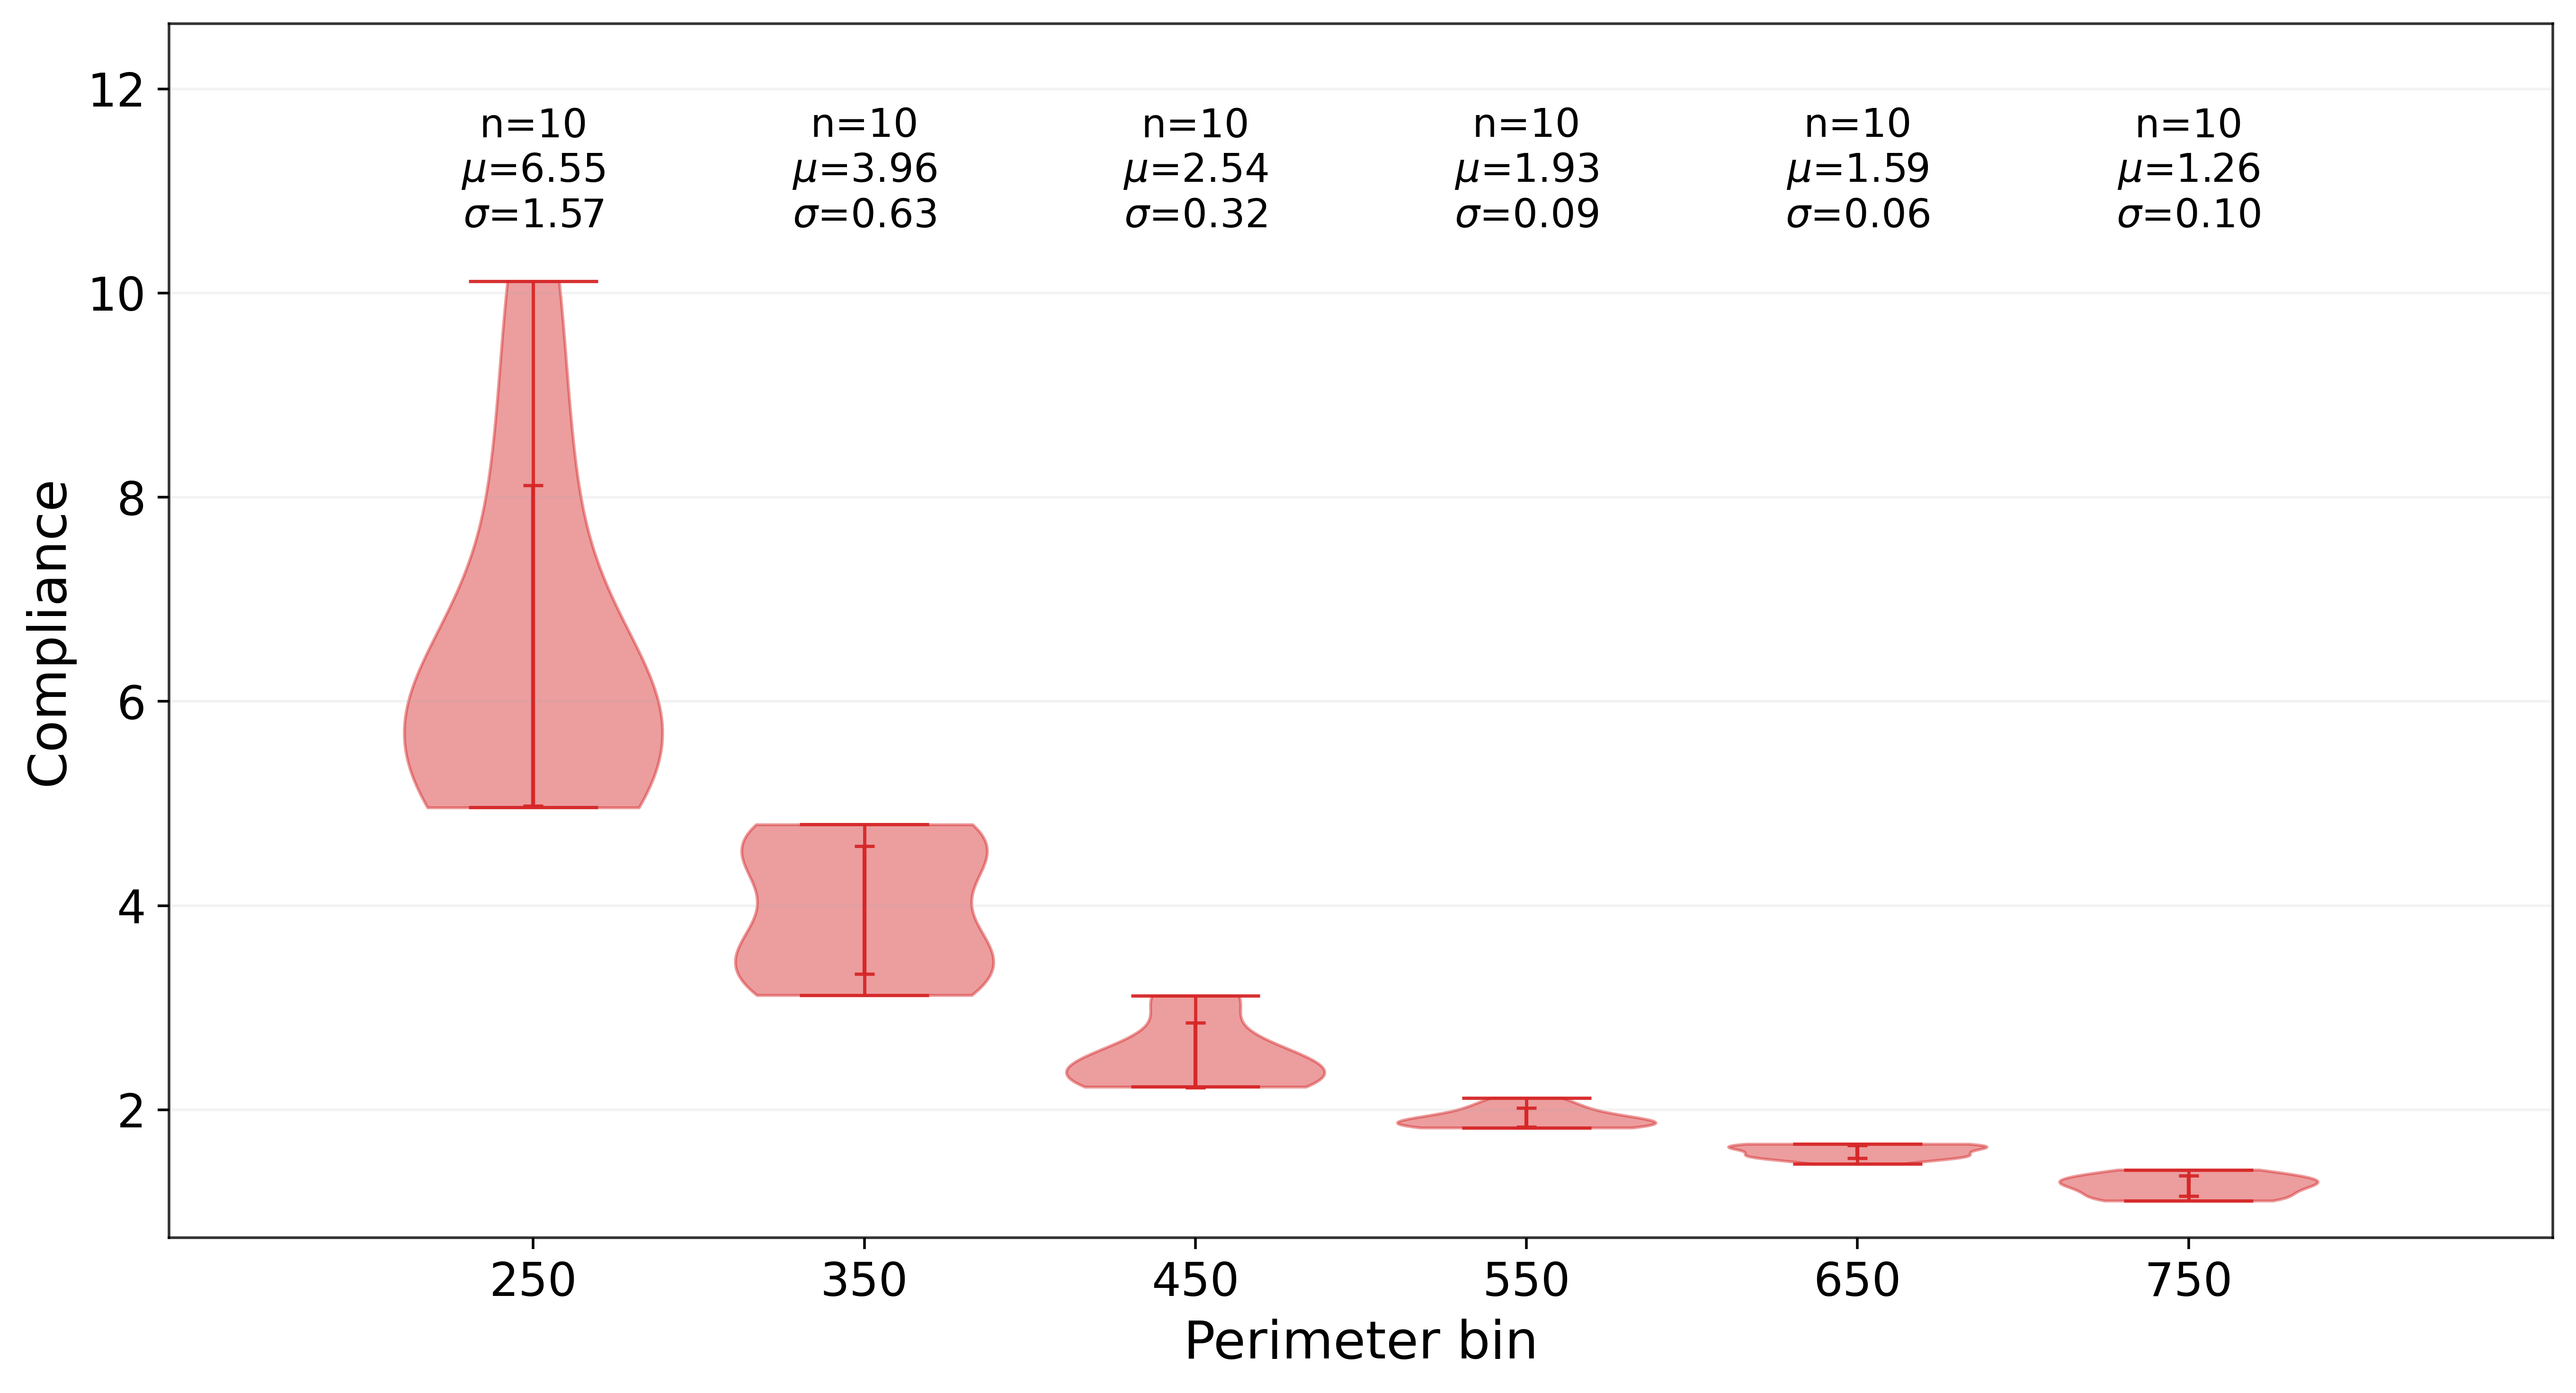

In [292]:
plot_bulb_violin_by_bins(oc_df_capped, kernel_color, "OC")

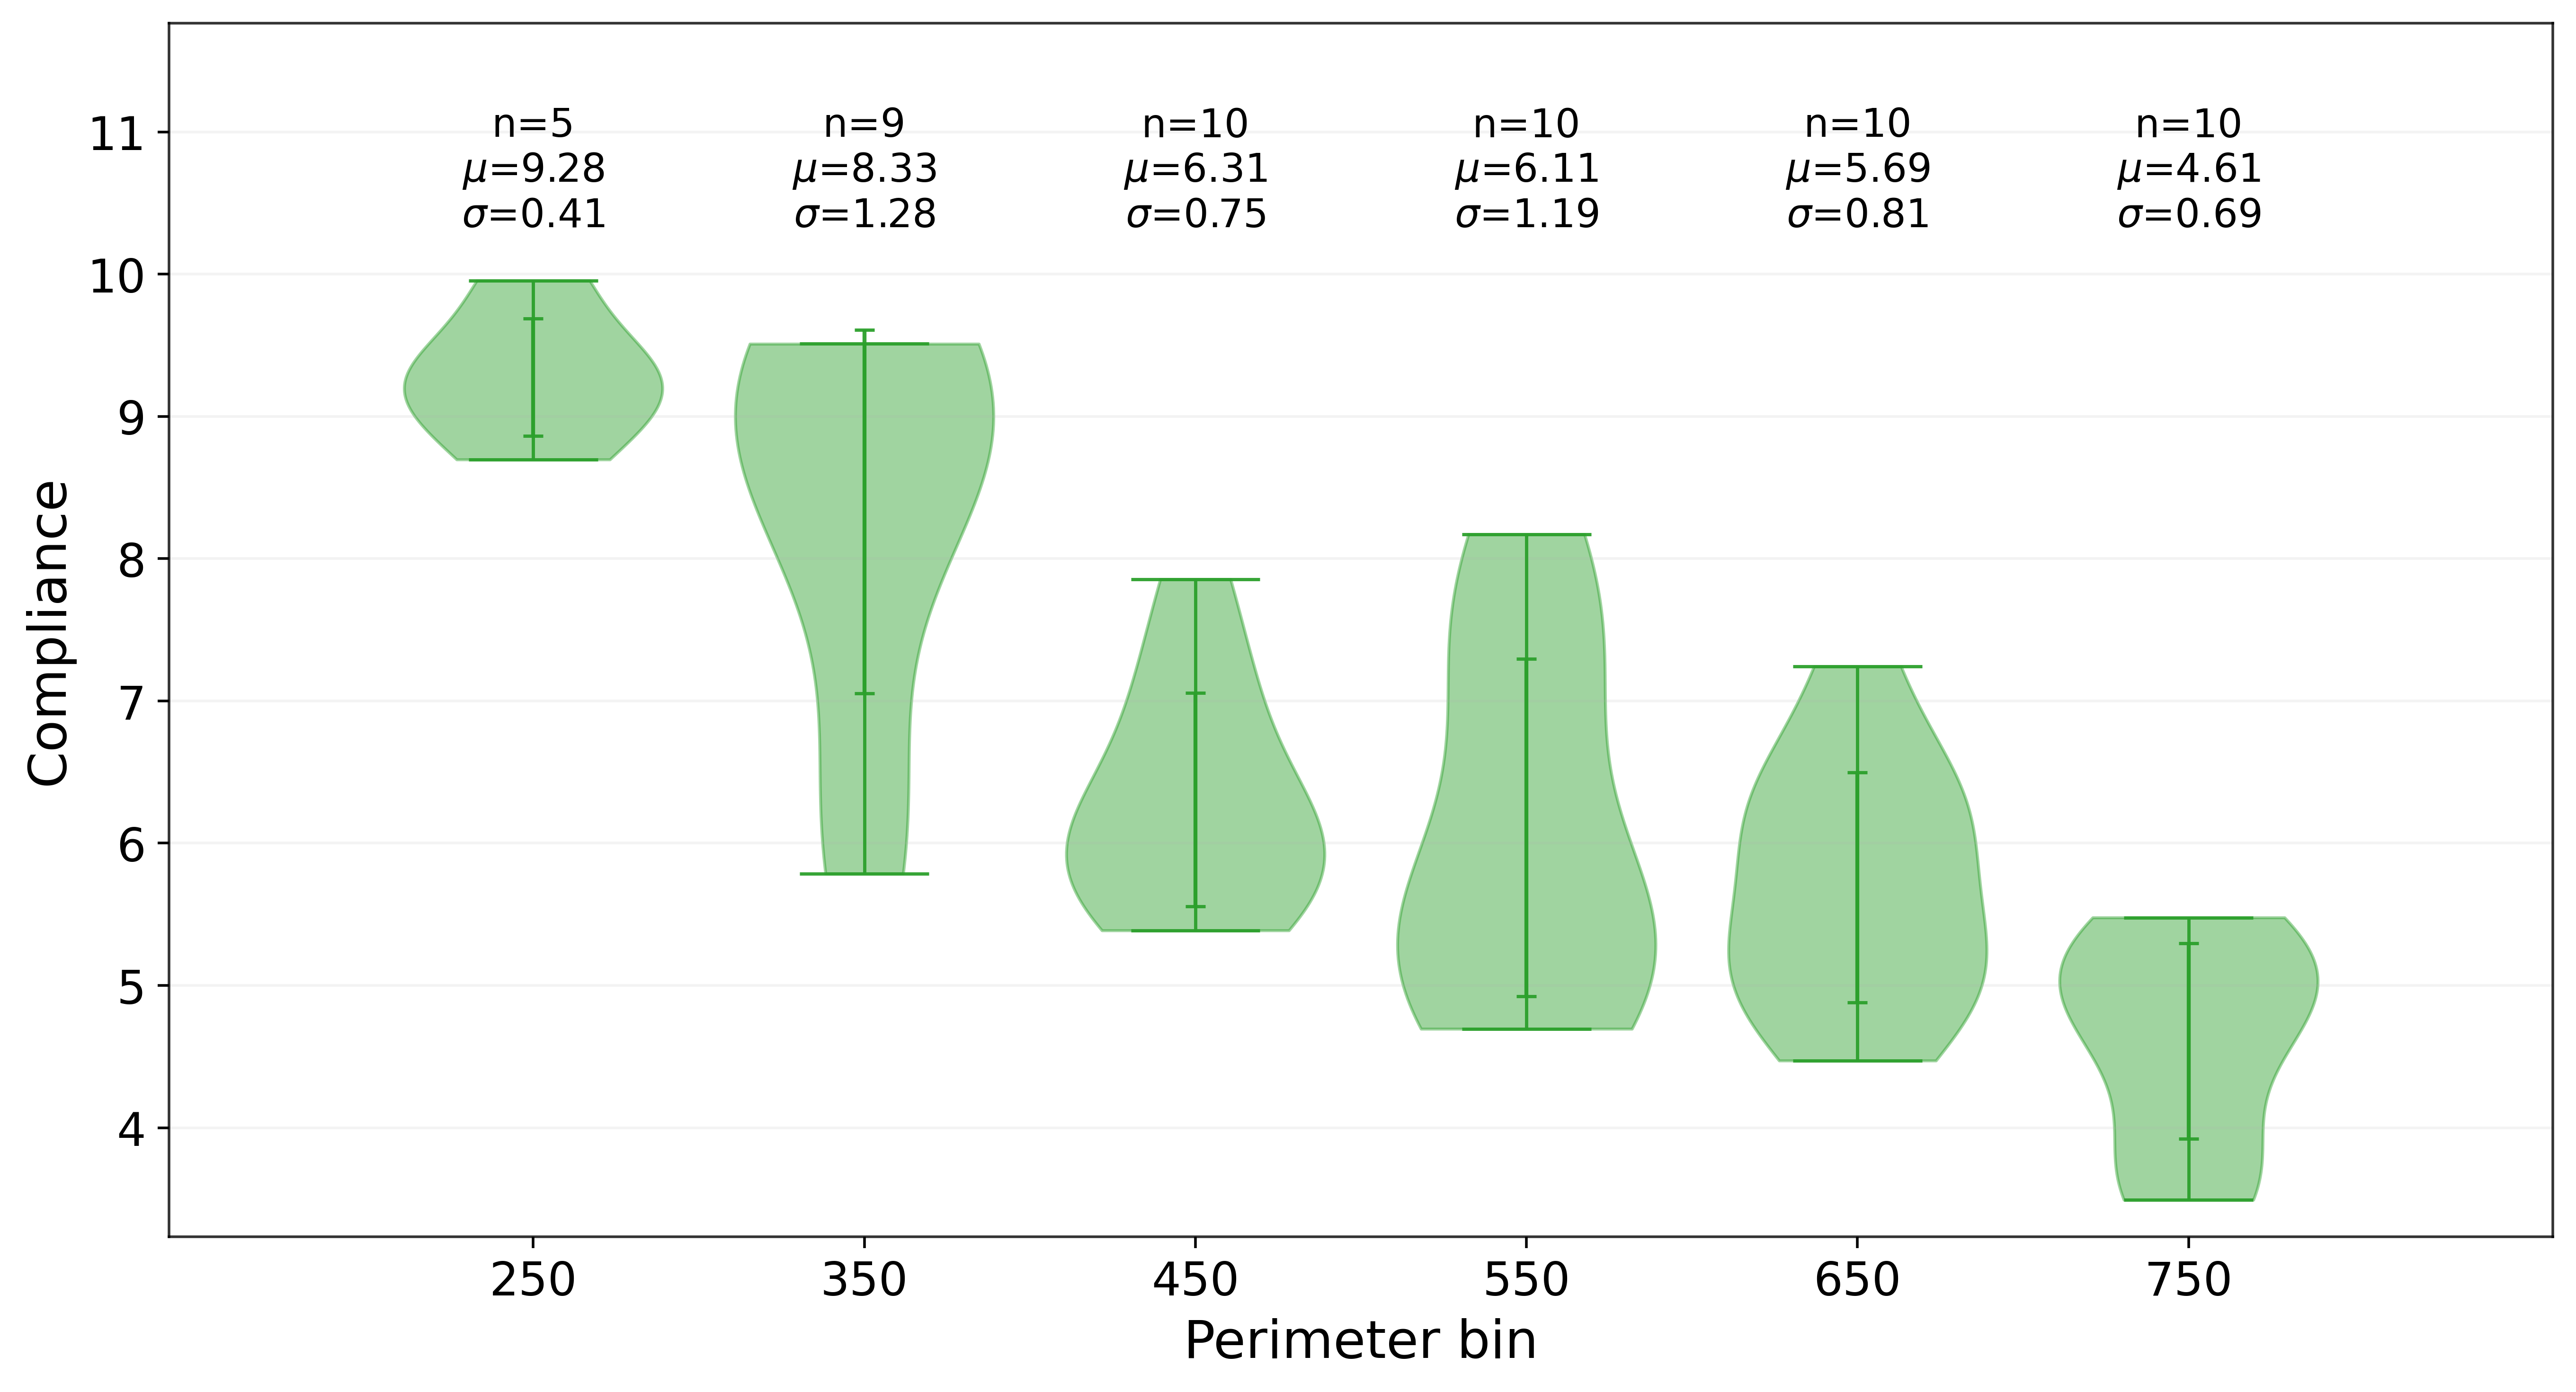

In [293]:
plot_bulb_violin_by_bins(fenics_df_capped, fenics_color, "FEniCS Smooth")

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path


if "bin_starts" not in globals() or "bin_ends" not in globals():
    raise ValueError("bin_starts and bin_ends must be defined before plotting runtimes.")


def _median_or_nan(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    return float(np.median(arr))


def _bin_mask(df, left_edge, right_edge):
    return (df["perimeter"] >= left_edge) & (df["perimeter"] < right_edge)


def _admm_runtime_parts(alpha, dim, base_dir, cache):
    key = (float(alpha), int(dim), str(base_dir))
    if key not in cache:
        trial = ADMMColin(alpha=float(alpha), dim=int(dim), base_dir=str(base_dir)).trial(0)
        runtime_sub1 = float(np.sum(trial.series.runtime_sub1))
        runtime_sub2 = float(np.sum(trial.series.runtime_sub2))
        cache[key] = (runtime_sub1, runtime_sub2)
    return cache[key]


def _oc_runtime_total(path):
    with h5py.File(path, "r") as h5f:
        return float(h5f.attrs.get("runtime_template_filter_algo", np.nan))


def _fenics_runtime_total(alpha, dim, path, base_dir, cache):
    key = (float(alpha), int(dim), str(base_dir))
    if key not in cache:
        runtime_total = np.nan
        try:
            with h5py.File(path, "r") as h5f:
                runtime_total = float(h5f["summary"].attrs.get("runtime_total", np.nan))
        except Exception:
            runtime_total = np.nan

        if not np.isfinite(runtime_total):
            fenics_run = fenicsModel(alpha=float(alpha), n=int(dim), base_dir=str(base_dir))
            runtime_total = float(
                getattr(fenics_run, "total_runtime", getattr(fenics_run, "runtime_total", np.nan))
            )
        cache[key] = runtime_total
    return cache[key]


admm_cache = {}
fenics_cache = {}
fenics_base_dir = "relax_and_round_smooth/fenics_model_tri_1e-06"
centers = 0.5 * (bin_starts + bin_ends)

admm_sub1_medians = []
admm_sub2_medians = []
admm_mip_sub1_medians = []
admm_mip_sub2_medians = []
oc_total_medians = []
fenics_total_medians = []

for left_edge, right_edge in zip(bin_starts, bin_ends):
    admm_bin = admm_df_capped.loc[_bin_mask(admm_df_capped, left_edge, right_edge)]
    admm_sub1 = []
    admm_sub2 = []
    for _, row in admm_bin.iterrows():
        runtime_sub1, runtime_sub2 = _admm_runtime_parts(
            row["alpha"], row["dim"], "admm_colin/run_data_admm_gurobi_sample", admm_cache
        )
        admm_sub1.append(runtime_sub1)
        admm_sub2.append(runtime_sub2)
    admm_sub1_medians.append(_median_or_nan(admm_sub1))
    admm_sub2_medians.append(_median_or_nan(admm_sub2))

    admm_mip_bin = admm_mip_df_capped.loc[_bin_mask(admm_mip_df_capped, left_edge, right_edge)]
    admm_mip_sub1 = []
    admm_mip_sub2 = []
    for _, row in admm_mip_bin.iterrows():
        runtime_sub1, runtime_sub2 = _admm_runtime_parts(
            row["alpha"], row["dim"], "admm_colin/run_data_admm_gurobi_mip", admm_cache
        )
        admm_mip_sub1.append(runtime_sub1)
        admm_mip_sub2.append(runtime_sub2)
    admm_mip_sub1_medians.append(_median_or_nan(admm_mip_sub1))
    admm_mip_sub2_medians.append(_median_or_nan(admm_mip_sub2))

    oc_bin = oc_df_capped.loc[_bin_mask(oc_df_capped, left_edge, right_edge)]
    oc_total_medians.append(_median_or_nan([_oc_runtime_total(path) for path in oc_bin["path"]]))

    fenics_bin = fenics_df_capped.loc[_bin_mask(fenics_df_capped, left_edge, right_edge)]
    fenics_total_medians.append(
        _median_or_nan(
            [
                _fenics_runtime_total(row["alpha"], row["dim"], row["path"], fenics_base_dir, fenics_cache)
                for _, row in fenics_bin.iterrows()
            ]
        )
    )

admm_sub1_medians = np.asarray(admm_sub1_medians, dtype=float)
admm_sub2_medians = np.asarray(admm_sub2_medians, dtype=float)
admm_mip_sub1_medians = np.asarray(admm_mip_sub1_medians, dtype=float)
admm_mip_sub2_medians = np.asarray(admm_mip_sub2_medians, dtype=float)
oc_total_medians = np.asarray(oc_total_medians, dtype=float)
fenics_total_medians = np.asarray(fenics_total_medians, dtype=float)

bin_width = float(bin_ends[0] - bin_starts[0]) if len(bin_starts) else 100.0
bar_w = 0.09 * bin_width
offsets = np.array([0, -1.5, -0.5, 0.5, 1.5, 2.5]) * bar_w

print("Median runtimes by bin:")
for center, a1, a2, m1, m2, oc_rt, fen_rt in zip(
    centers,
    admm_sub1_medians,
    admm_sub2_medians,
    admm_mip_sub1_medians,
    admm_mip_sub2_medians,
    oc_total_medians,
    fenics_total_medians,
):
    print(
        f"bin={center:.0f} | ADMM=({a1:.3f}, {a2:.3f}) | "
        f"ADMM-MIP=({m1:.3f}, {m2:.3f}) | OC={oc_rt:.3f} | FEniCS={fen_rt:.3f}"
    )

Median runtimes by bin:
bin=250 | ADMM=(49.350, 397.365) | ADMM-MIP=(65.852, 862.964) | OC=10.462 | FEniCS=137.914
bin=350 | ADMM=(47.598, 374.402) | ADMM-MIP=(65.669, 751.131) | OC=10.234 | FEniCS=30.727
bin=450 | ADMM=(45.024, 370.183) | ADMM-MIP=(66.634, 592.561) | OC=10.386 | FEniCS=5.406
bin=550 | ADMM=(48.797, 401.296) | ADMM-MIP=(66.489, 502.344) | OC=11.216 | FEniCS=5.244
bin=650 | ADMM=(46.393, 396.984) | ADMM-MIP=(66.087, 480.884) | OC=14.739 | FEniCS=5.362
bin=750 | ADMM=(51.700, 519.201) | ADMM-MIP=(67.907, 478.132) | OC=4.341 | FEniCS=5.123


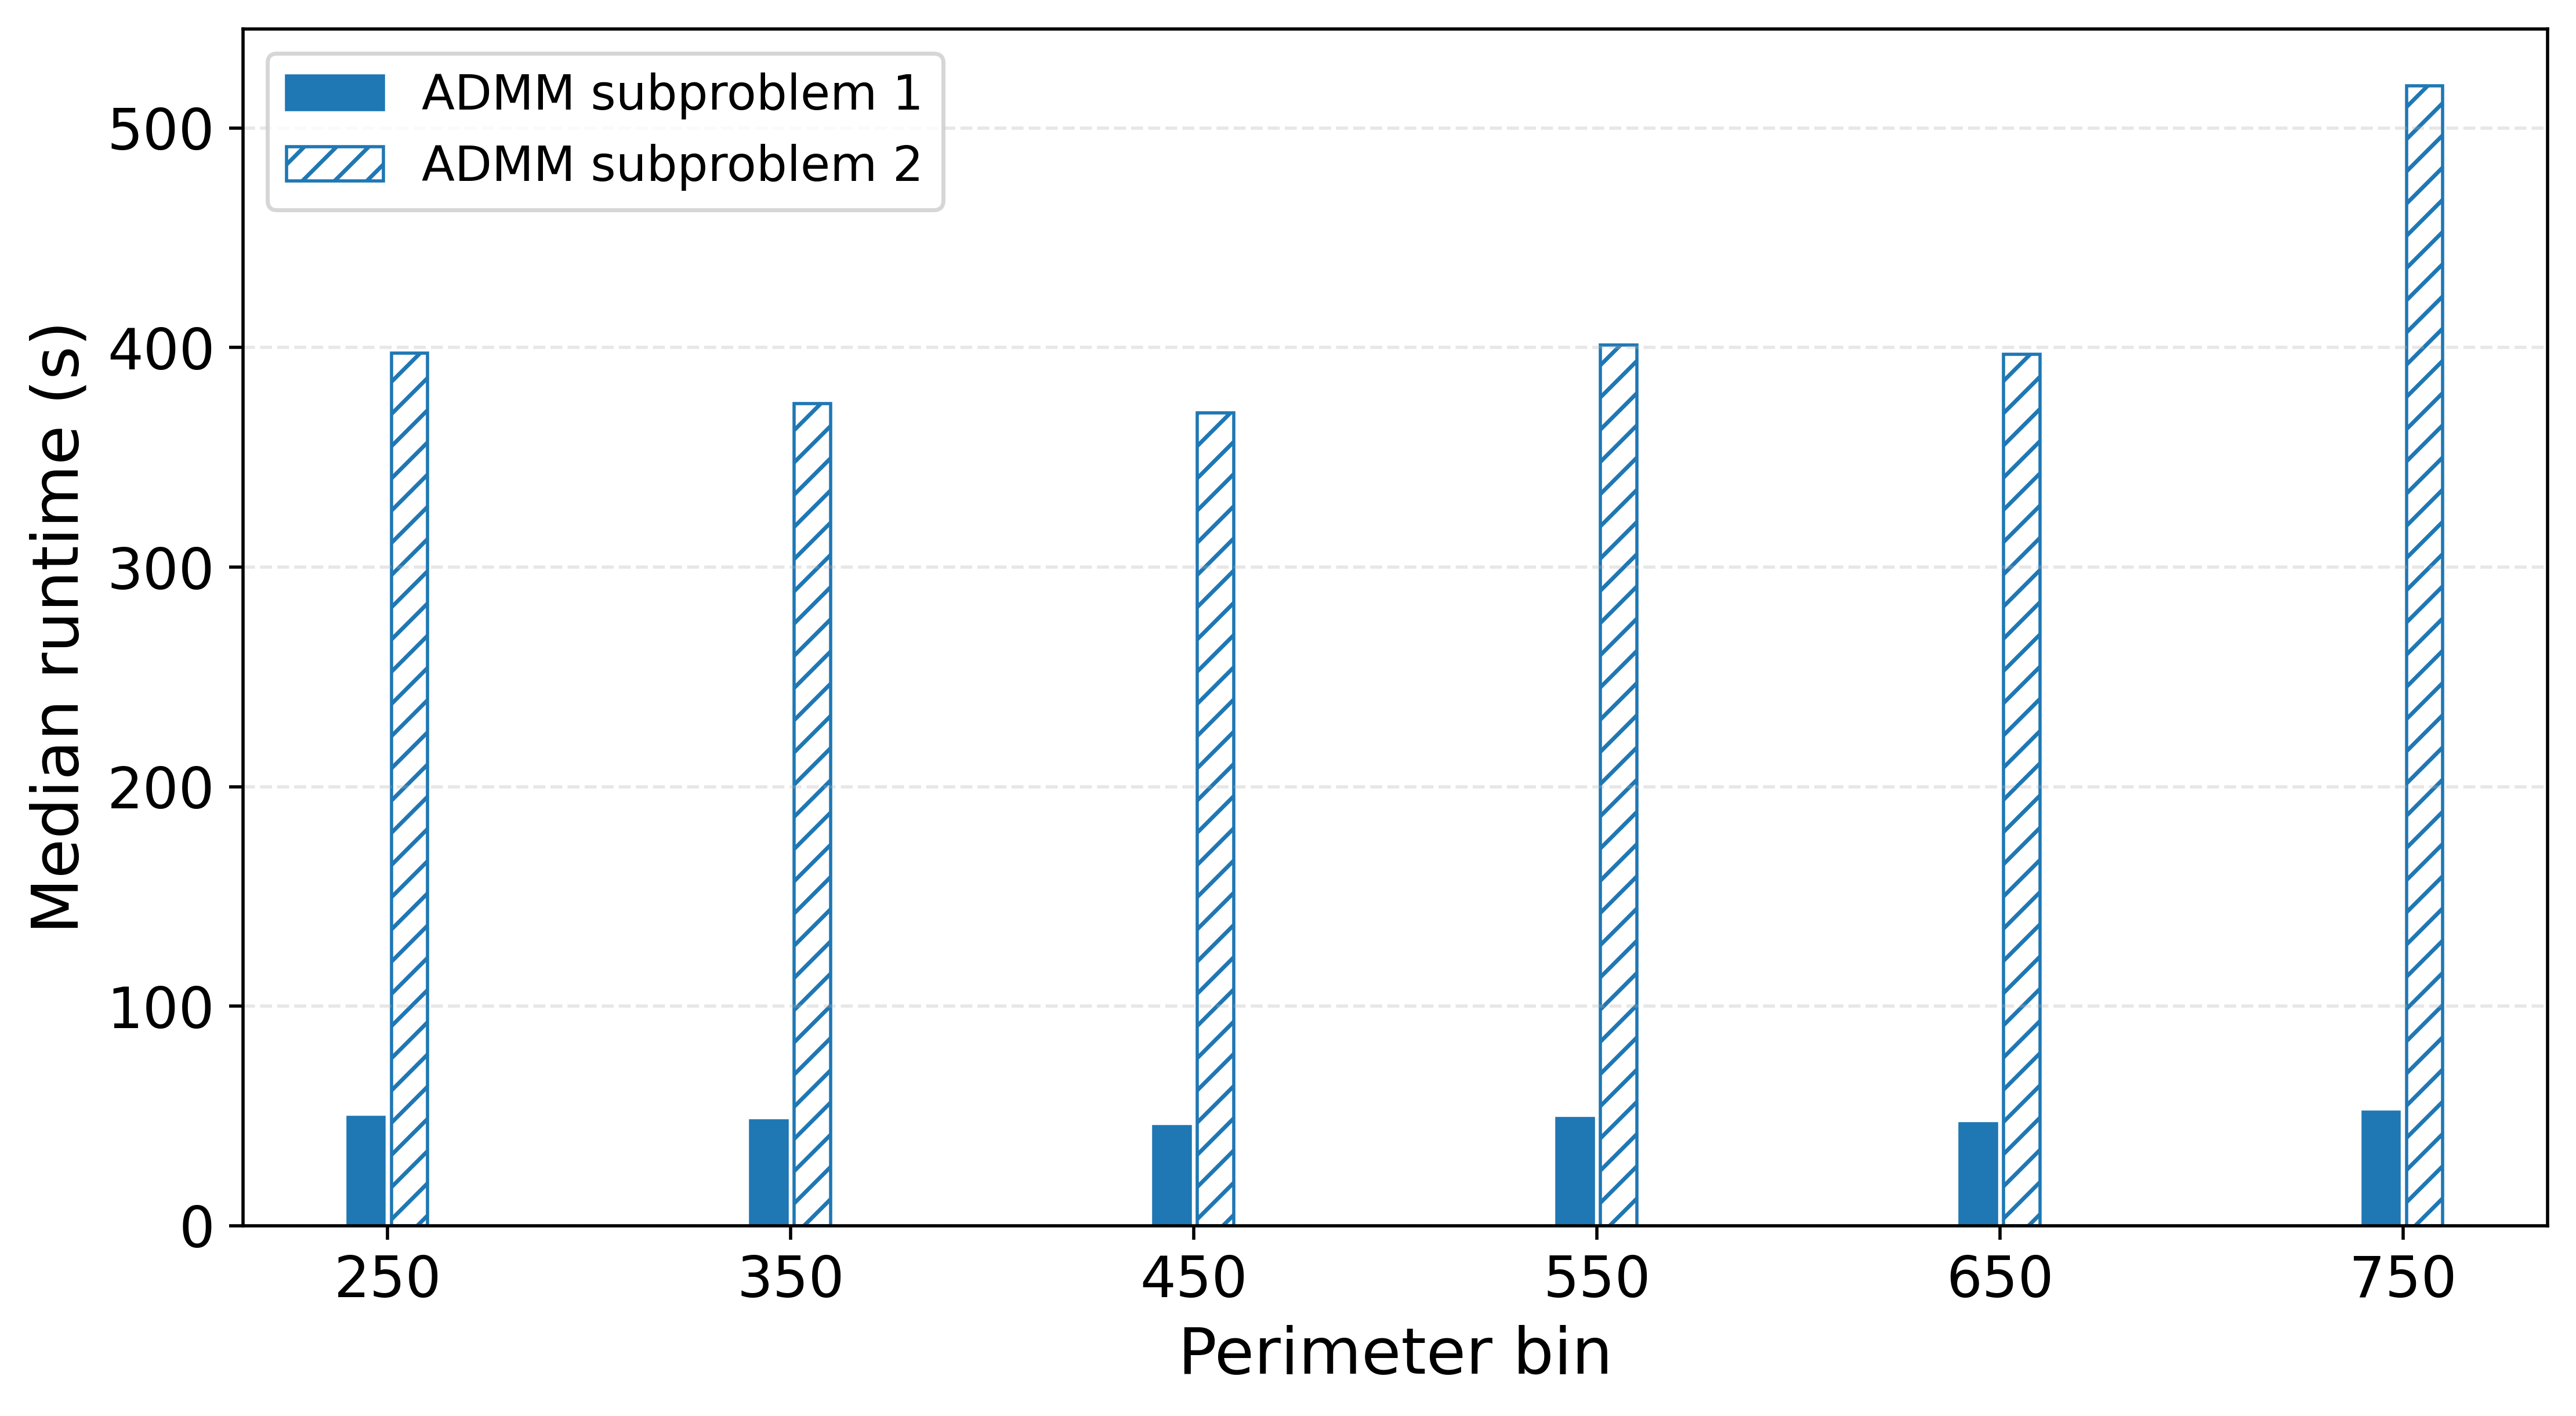

In [61]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(centers - 0.6*bar_w, admm_sub1_medians, width=bar_w, color=admm_color, edgecolor=admm_color, linewidth=0.8, label="ADMM subproblem 1")
ax.bar(centers + 0.6*bar_w, admm_sub2_medians, width=bar_w, color="white", edgecolor=admm_color, linewidth=0.8, hatch="///", label="ADMM subproblem 2")

ax.set_xticks(centers)
ax.set_xticklabels([f"{int(c)}" for c in centers])
ax.set_xlabel("Perimeter bin", fontsize=16)
ax.set_ylabel("Median runtime (s)", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(frameon=True, fontsize=12, ncol=1)
plt.tight_layout()
plt.gcf().set_dpi(500)
plt.show()

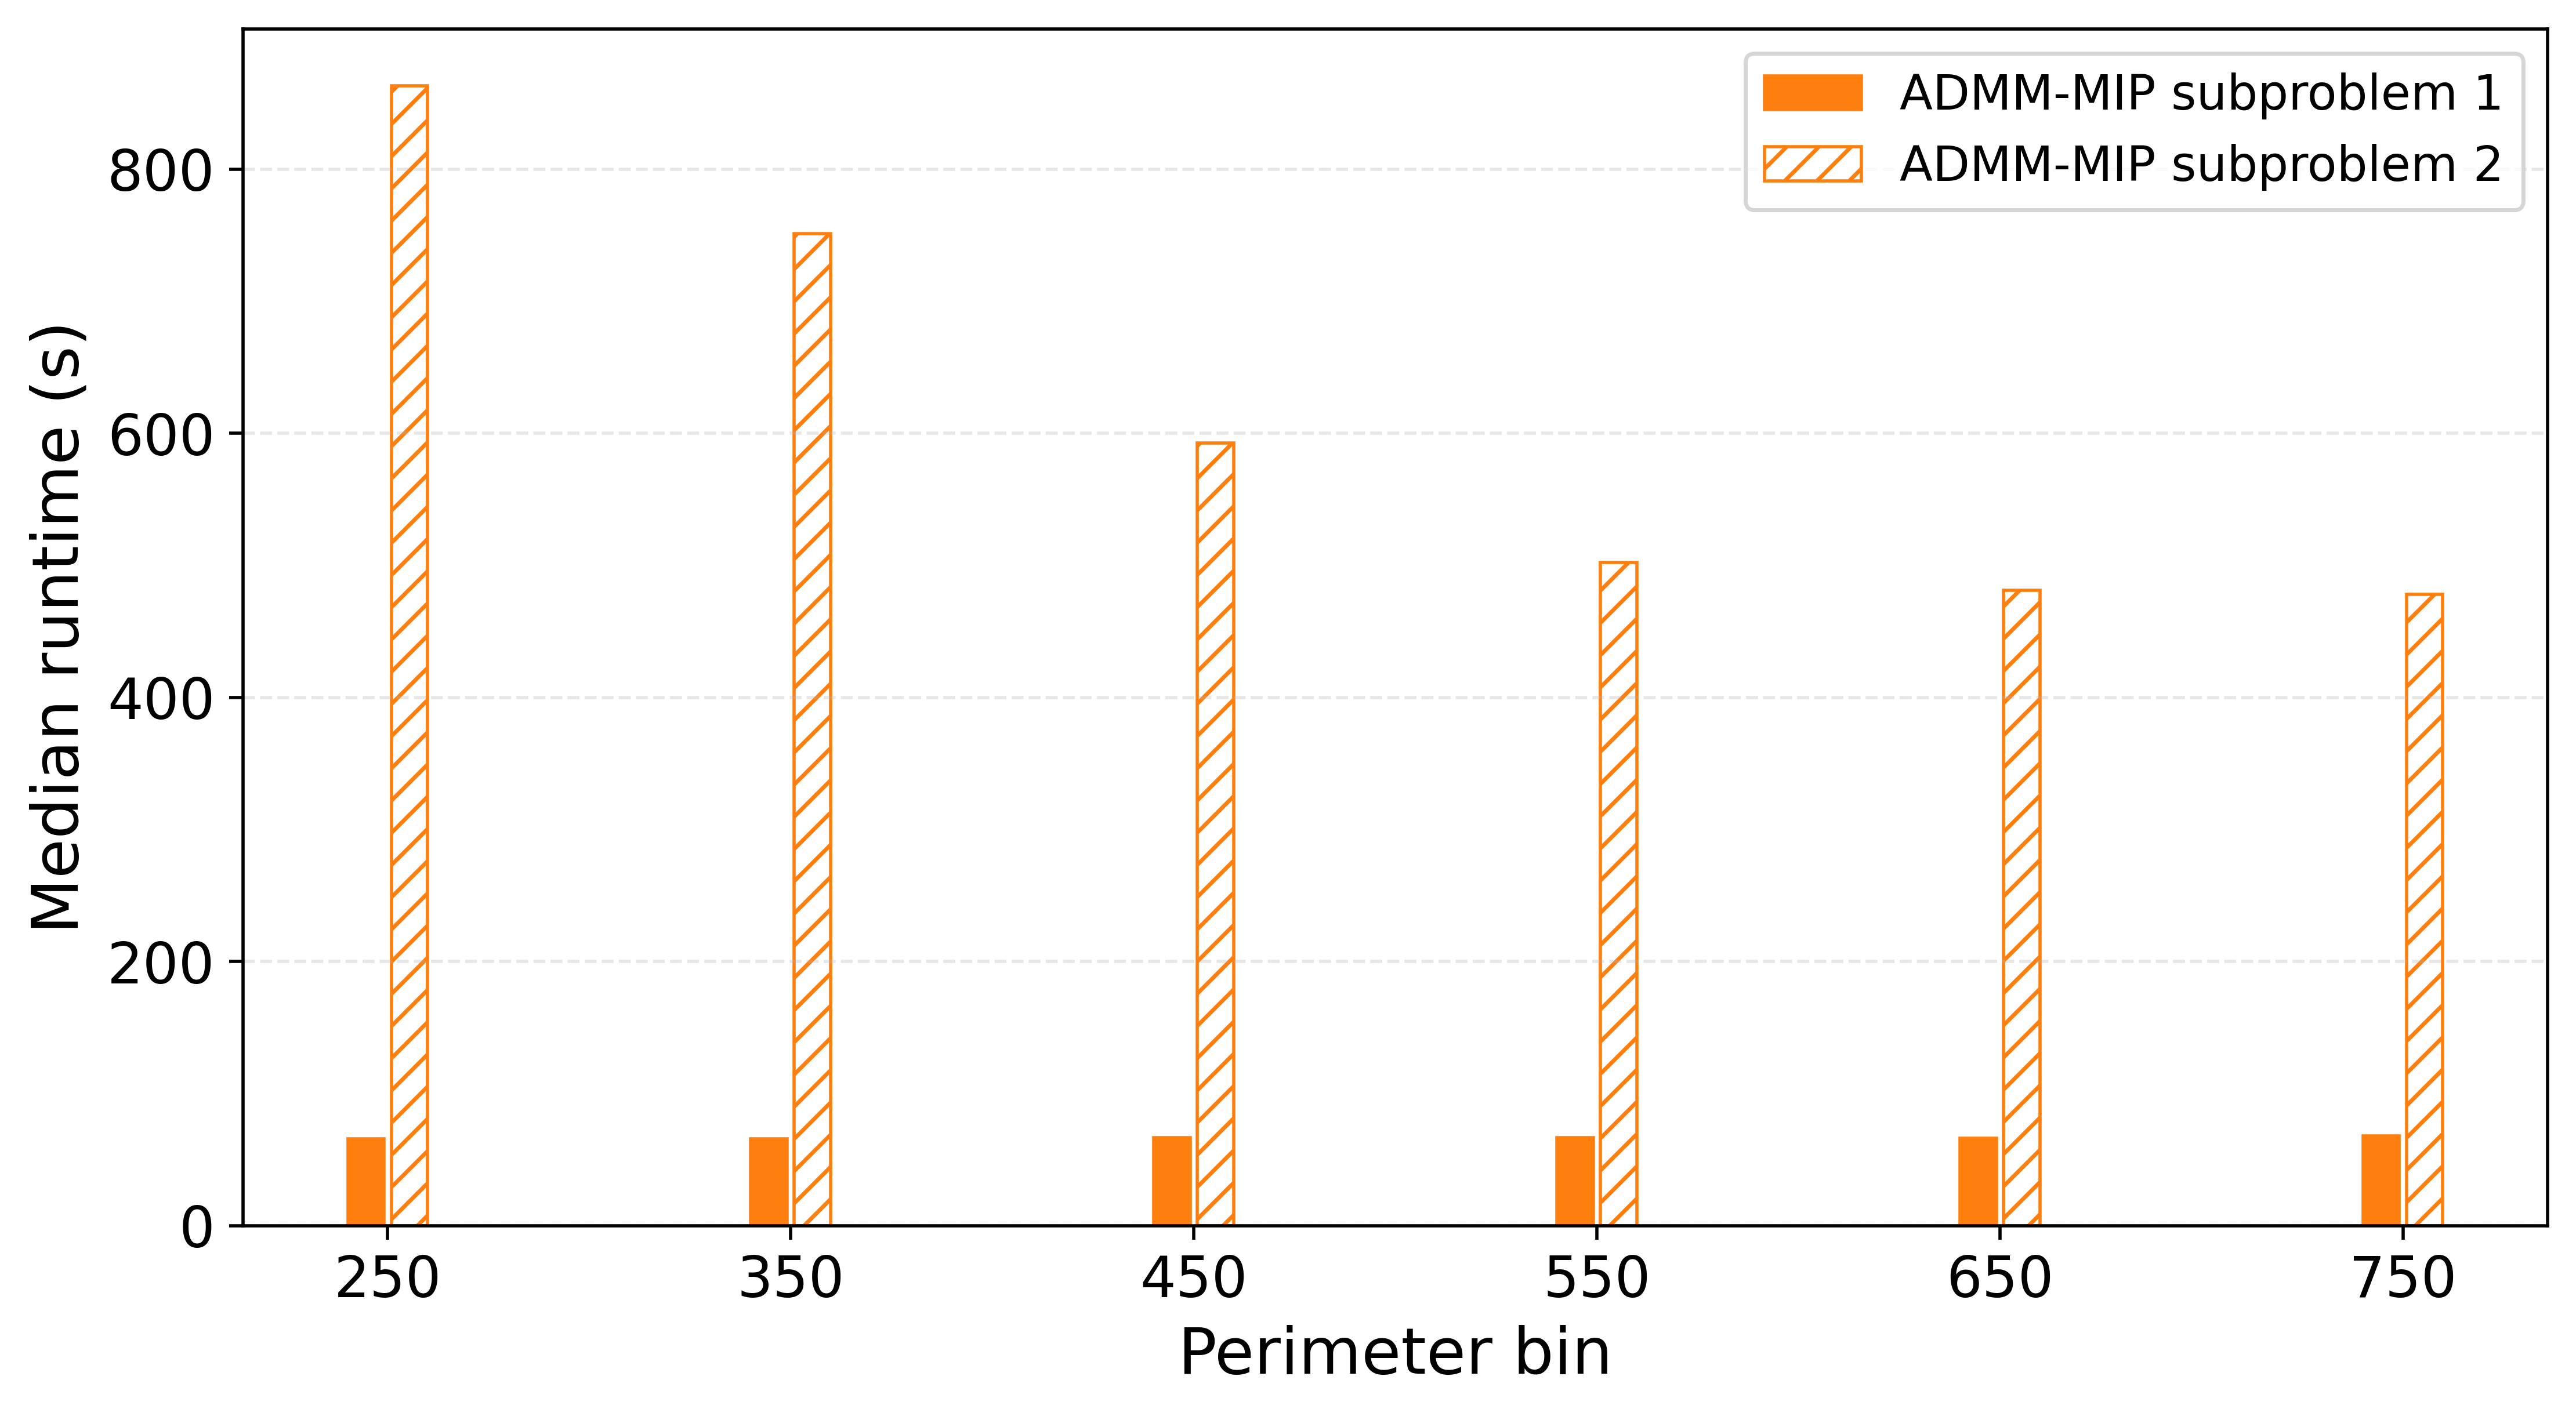

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
plt.bar(centers - 0.6*bar_w, admm_mip_sub1_medians, width=bar_w, color=admm_mip_color, edgecolor=admm_mip_color, linewidth=0.8, label="ADMM-MIP subproblem 1")
plt.bar(centers + 0.6*bar_w, admm_mip_sub2_medians, width=bar_w, color="white", edgecolor=admm_mip_color, linewidth=0.8, hatch="///", label="ADMM-MIP subproblem 2")
ax.set_xticks(centers)
ax.set_xticklabels([f"{int(c)}" for c in centers])
ax.set_xlabel("Perimeter bin", fontsize=16)
ax.set_ylabel("Median runtime (s)", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(frameon=True, fontsize=12, ncol=1)
plt.tight_layout()
plt.gcf().set_dpi(500)
plt.show()

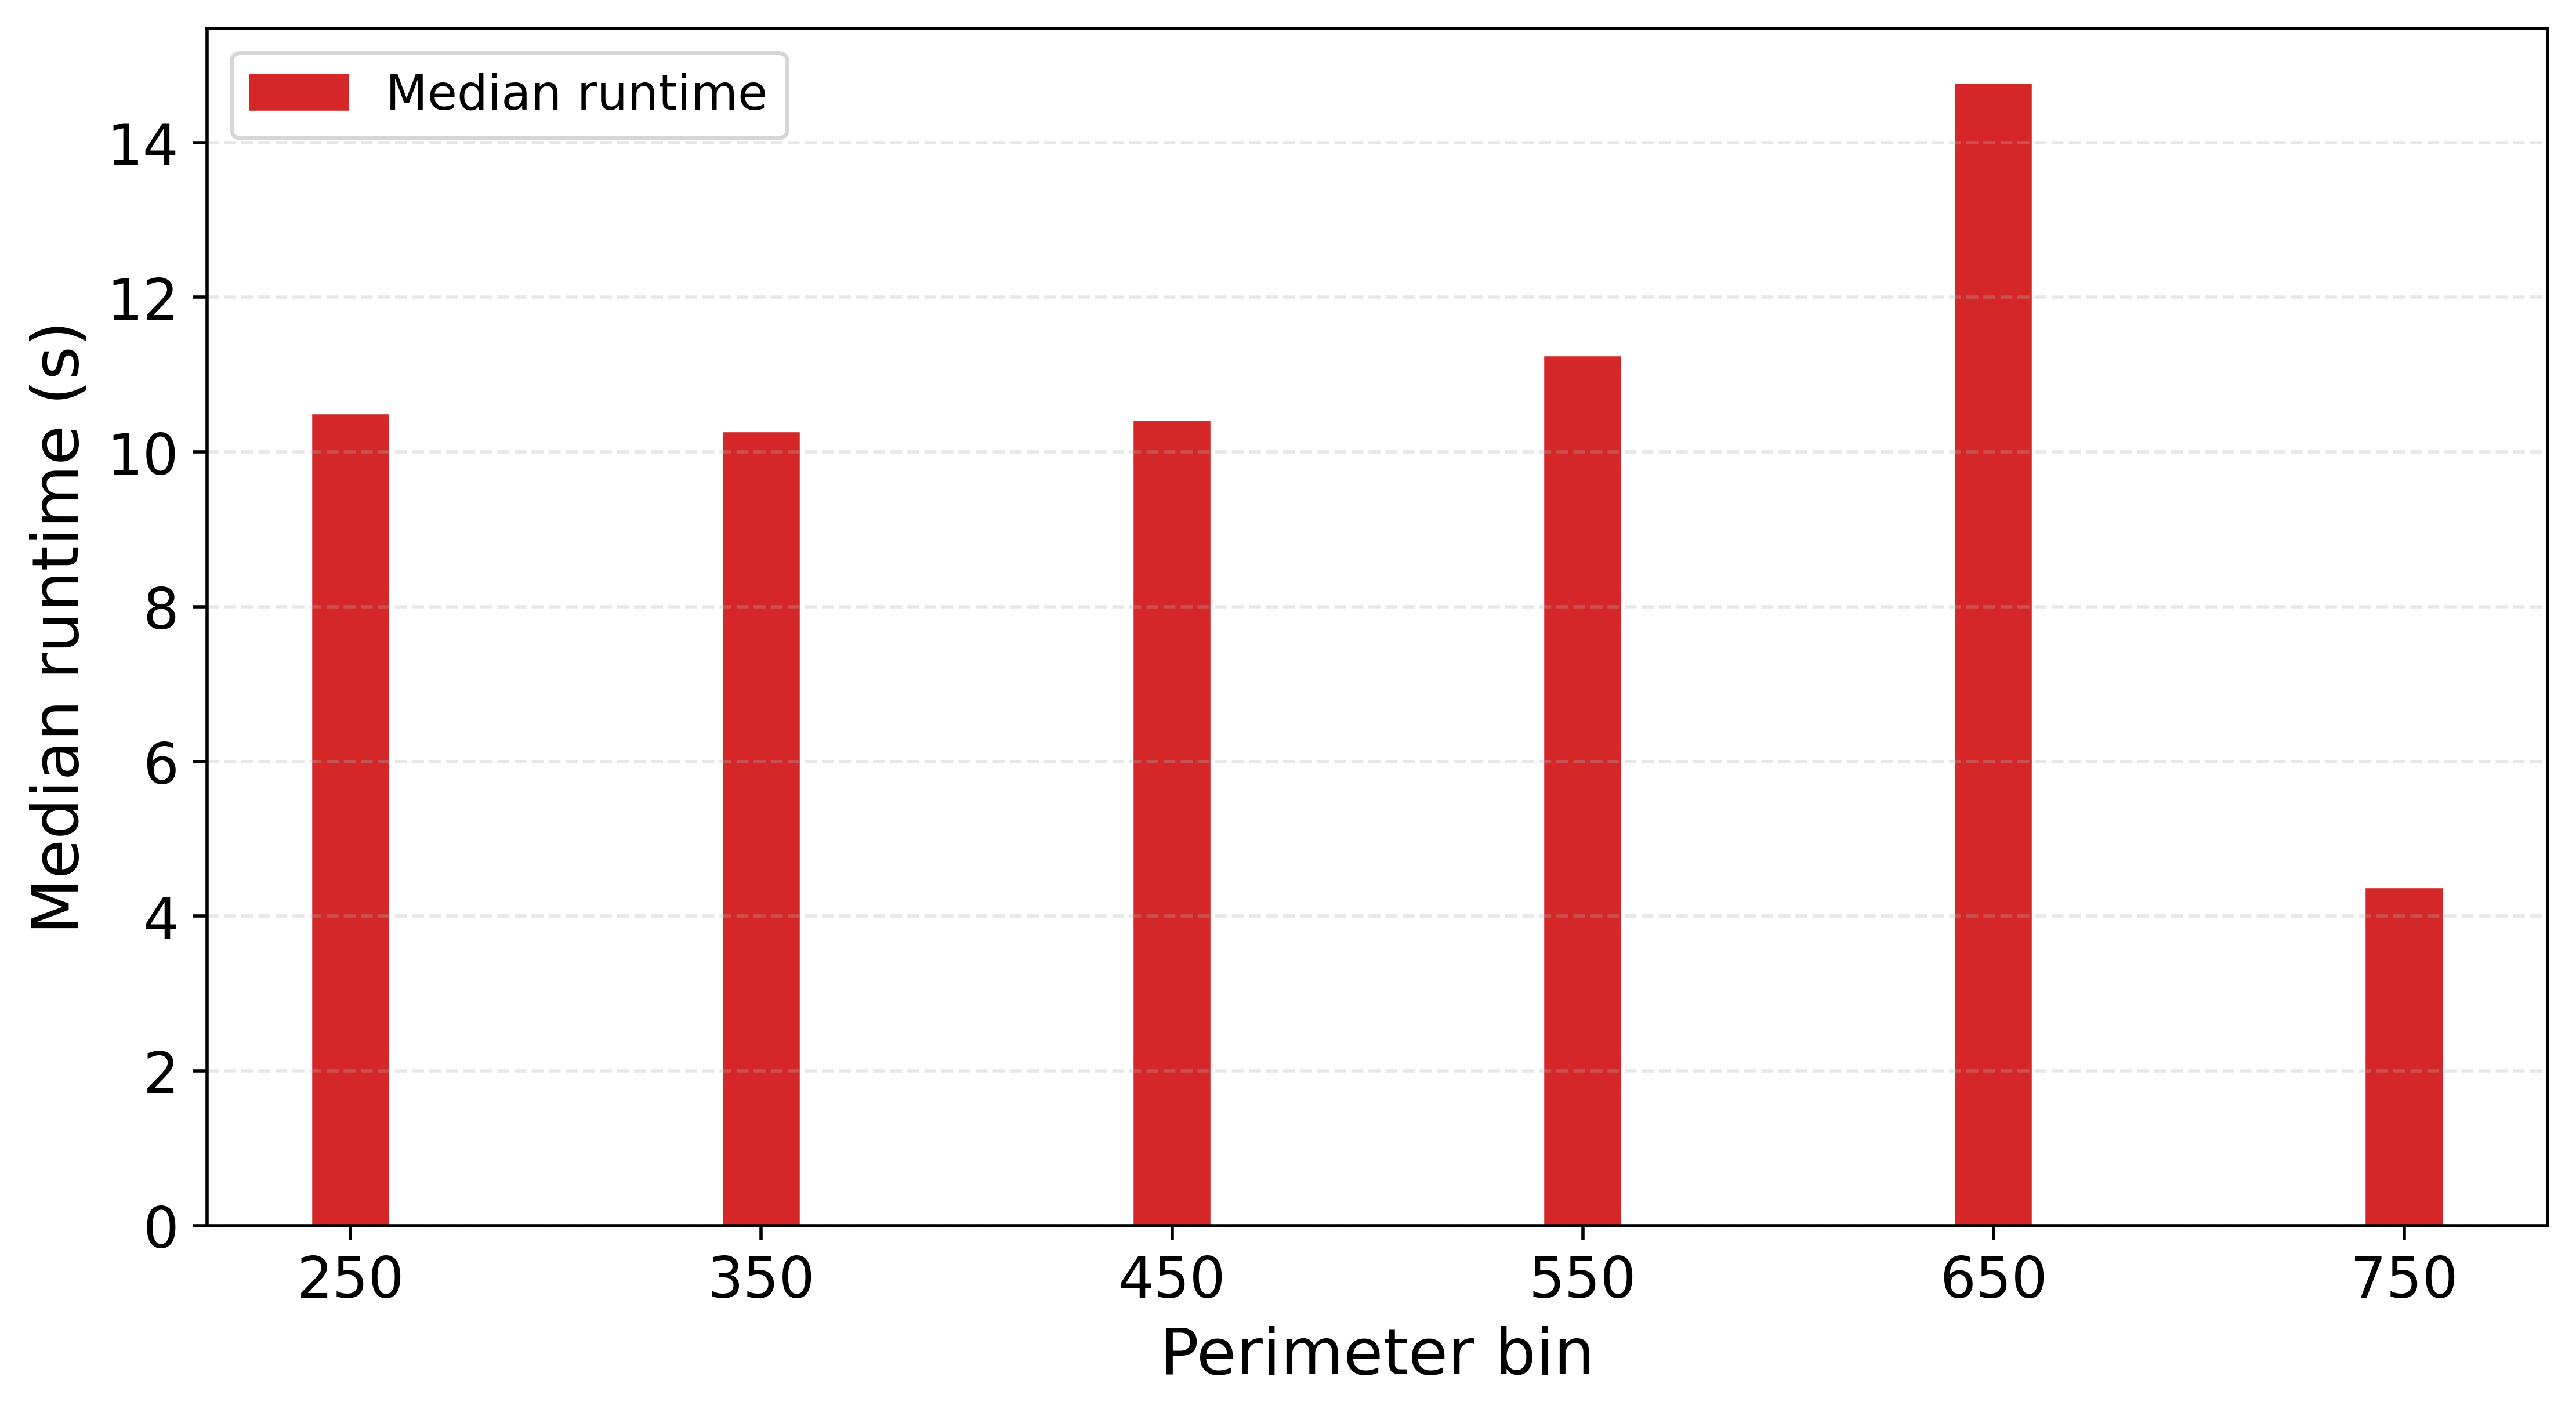

In [63]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(centers, oc_total_medians, width=2*bar_w, color=kernel_color, edgecolor=kernel_color, linewidth=0.8, label="Median runtime")
ax.set_xticks(centers)
ax.set_xticklabels([f"{int(c)}" for c in centers])
ax.set_xlabel("Perimeter bin", fontsize=16)
ax.set_ylabel("Median runtime (s)", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(frameon=True, fontsize=12, ncol=1)
plt.tight_layout()
plt.gcf().set_dpi(500)
plt.show()


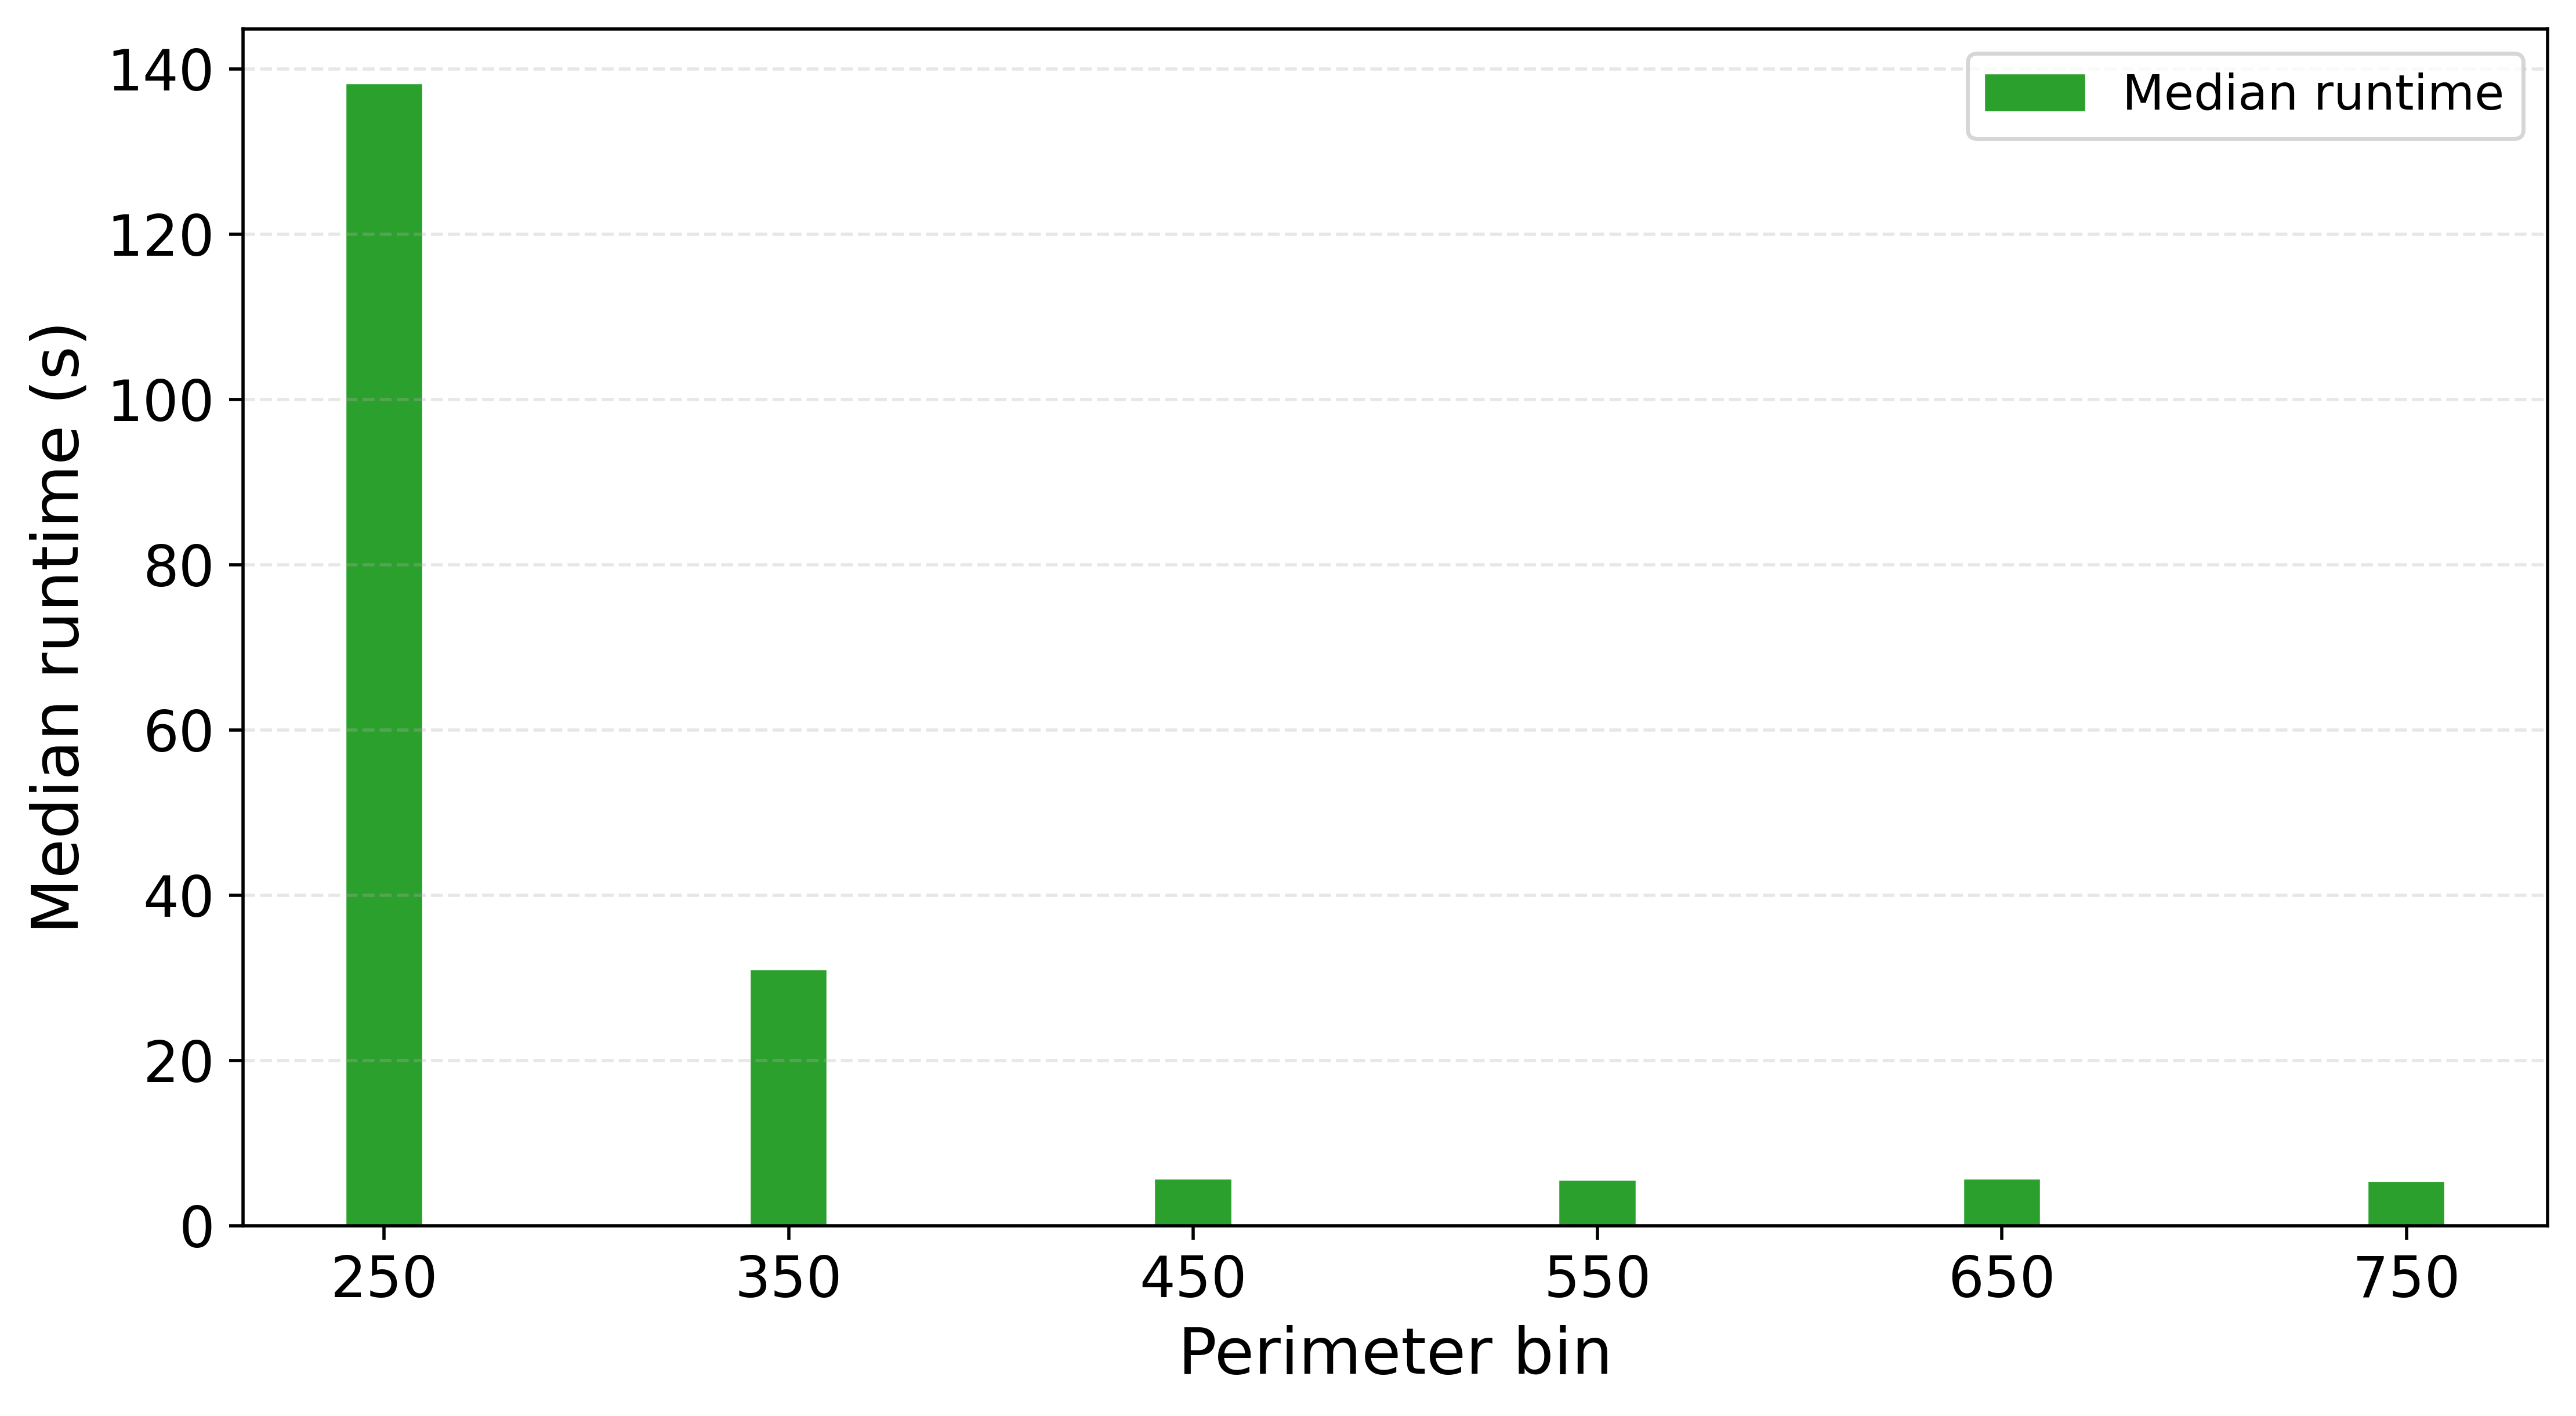

In [299]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(centers, fenics_total_medians, width=2*bar_w, color=fenics_color, edgecolor=fenics_color, linewidth=0.8, label="Median runtime")
ax.set_xticks(centers)
ax.set_xticklabels([f"{int(c)}" for c in centers])
ax.set_xlabel("Perimeter bin", fontsize=16)
ax.set_ylabel("Median runtime (s)", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(frameon=True, fontsize=12, ncol=1, loc="upper right")
plt.tight_layout()
plt.gcf().set_dpi(500)
plt.show()